# 05 Epistasis analysis

This notebook reproduces the dissertation-associated epistasis analysis figures and tables from the processed W/O genotype landscape.

Target outputs:

- Figure 3.12: Pairwise epistasis heatmaps across experimental libraries
- Figure 3.13: Distribution of pairwise epistasis across genetic backgrounds
- Figure 3.14: Cross-library comparison of signed pairwise epistasis
- Figure 3.15: Pairwise epistatic interaction network
- Figure 3.16: Variance decomposition of the landscape by epistasis order
- Figure 3.17: Distribution of third-order epistasis across genetic background
- Figure 3.18: Cross-library comparison of third-order epistatic interaction coefficients
- Table 3.7: Cross-library correlation of pairwise epistasis estimates

Network and path analyses are handled separately in `04_network_and_path_analysis.ipynb`.
Collaborator/model-comparison analyses are handled separately after this notebook.

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yaml

from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import networkx as nx

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures" / "epistasis"
CONFIG_PATH = PROJECT_ROOT / "config" / "analysis_config.yml"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

EPSILON = float(config["epsilon"])
MIN_SAMPLE_TOTAL_UMI = int(config["min_sample_total_umi"])

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Checkpoint output:", CHECKPOINT_DIR)
print("Figure output:", FIGURE_DIR)
print("Config path:", CONFIG_PATH)
print("EPSILON:", EPSILON)
print("Configured MIN_SAMPLE_TOTAL_UMI:", MIN_SAMPLE_TOTAL_UMI)

Project root: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape
Processed data: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/data/processed
Checkpoint output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/outputs/checkpoints
Figure output: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/figures/epistasis
Config path: /Users/jonathanfelix/Documents/Dissertation_GitHub/rbd-epistasis-landscape/config/analysis_config.yml
EPSILON: 1e-06
Configured MIN_SAMPLE_TOTAL_UMI: 0


In [2]:
landscape = pd.read_csv(PROCESSED_DIR / "WO_landscape_per_library.csv")

print("landscape:", landscape.shape)
print("columns:", list(landscape.columns))

landscape.head()

landscape: (768, 11)
columns: ['library_id', 'wo', 'Neg', 'Pos', 'Pre', 'log2fc_pos_pre', 'log2fc_neg_pre', 'delta_pos', 'delta_neg', 'mut_count', 'ddelta']


,library_id,wo,Neg,Pos,Pre,log2fc_pos_pre,log2fc_neg_pre,delta_pos,delta_neg,mut_count,ddelta
0,1,OOOOOOOO,0.005949,0.008597,0.003254,1.401357,0.870073,0.005343,0.002694,8,0.531285
1,1,OOOOOOOW,0.001347,0.001362,0.001796,-0.398696,-0.414820,-0.000434,-0.000449,7,0.016124
2,1,OOOOOOWO,0.003486,0.001391,0.002819,-1.018301,0.306112,-0.001428,0.000667,7,-1.324413
3,1,OOOOOOWW,0.003220,0.000169,0.004767,-4.807749,-0.565828,-0.004598,-0.001547,6,-4.241921
4,1,OOOOOWOO,0.000682,0.000340,0.000464,-0.450684,0.553312,-0.000125,0.000218,7,-1.003995


In [3]:
assert landscape.shape[0] == 3 * 256, "Expected 3 libraries x 256 genotypes."
assert landscape["wo"].str.len().eq(8).all(), "All W/O genotypes should have length 8."
assert set(landscape["library_id"]) == {1, 2, 3}, "Expected libraries 1, 2, and 3."

coverage = (
    landscape
    .groupby("library_id", as_index=False)
    .agg(
        n_genotypes=("wo", "nunique"),
        n_rows=("wo", "size")
    )
)

assert coverage["n_genotypes"].eq(256).all(), (
    "Each library should contain 256 genotypes."
)

coverage

,library_id,n_genotypes,n_rows
0,1,256,256
1,2,256,256
2,3,256,256


In [4]:
SITE_LABELS = ["477", "478", "484", "493", "496", "498", "501", "505"]

# Primary epistasis response used for the dissertation epistasis section.
# We can adjust this if the monolith shows a different source metric.
EPISTASIS_RESPONSE = "ddelta"

def encode_wo_genotype(genotype: str) -> dict:
    """
    Encode W/O genotype string as binary variables.
    
    W = 0
    O = 1
    """
    return {
        f"x_{site}": 1 if char == "O" else 0
        for site, char in zip(SITE_LABELS, genotype)
    }

encoded_genotypes = pd.DataFrame([
    {"wo": wo, **encode_wo_genotype(wo)}
    for wo in sorted(landscape["wo"].unique())
])

binary_cols = [f"x_{site}" for site in SITE_LABELS]

print("Epistasis response:", EPISTASIS_RESPONSE)
print("Binary columns:", binary_cols)

encoded_genotypes.head()

Epistasis response: ddelta
Binary columns: ['x_477', 'x_478', 'x_484', 'x_493', 'x_496', 'x_498', 'x_501', 'x_505']


,wo,x_477,x_478,x_484,x_493,x_496,x_498,x_501,x_505
0,OOOOOOOO,1,1,1,1,1,1,1,1
1,OOOOOOOW,1,1,1,1,1,1,1,0
2,OOOOOOWO,1,1,1,1,1,1,0,1
3,OOOOOOWW,1,1,1,1,1,1,0,0
4,OOOOOWOO,1,1,1,1,1,0,1,1


In [5]:
landscape_encoded = landscape.merge(
    encoded_genotypes,
    on="wo",
    how="left"
)

assert not landscape_encoded[binary_cols].isna().any().any(), (
    "Missing binary encoding values."
)

landscape_encoded = landscape_encoded.sort_values(
    ["library_id", "wo"]
).reset_index(drop=True)

landscape_encoded.head()

,library_id,wo,Neg,Pos,Pre,log2fc_pos_pre,log2fc_neg_pre,delta_pos,delta_neg,mut_count,ddelta,x_477,x_478,x_484,x_493,x_496,x_498,x_501,x_505
0,1,OOOOOOOO,0.005949,0.008597,0.003254,1.401357,0.870073,0.005343,0.002694,8,0.531285,1,1,1,1,1,1,1,1
1,1,OOOOOOOW,0.001347,0.001362,0.001796,-0.398696,-0.414820,-0.000434,-0.000449,7,0.016124,1,1,1,1,1,1,1,0
2,1,OOOOOOWO,0.003486,0.001391,0.002819,-1.018301,0.306112,-0.001428,0.000667,7,-1.324413,1,1,1,1,1,1,0,1
3,1,OOOOOOWW,0.003220,0.000169,0.004767,-4.807749,-0.565828,-0.004598,-0.001547,6,-4.241921,1,1,1,1,1,1,0,0
4,1,OOOOOWOO,0.000682,0.000340,0.000464,-0.450684,0.553312,-0.000125,0.000218,7,-1.003995,1,1,1,1,1,0,1,1


In [6]:
epistasis_input = landscape_encoded[
    [
        "library_id",
        "wo",
        "mut_count",
        EPISTASIS_RESPONSE,
        *binary_cols,
    ]
].copy()

epistasis_input.to_csv(
    CHECKPOINT_DIR / "epistasis_input_table.csv",
    index=False
)

epistasis_input.head()

,library_id,wo,mut_count,ddelta,x_477,x_478,x_484,x_493,x_496,x_498,x_501,x_505
0,1,OOOOOOOO,8,0.531285,1,1,1,1,1,1,1,1
1,1,OOOOOOOW,7,0.016124,1,1,1,1,1,1,1,0
2,1,OOOOOOWO,7,-1.324413,1,1,1,1,1,1,0,1
3,1,OOOOOOWW,6,-4.241921,1,1,1,1,1,1,0,0
4,1,OOOOOWOO,7,-1.003995,1,1,1,1,1,0,1,1


## Background-dependent epistasis calculations

Pairwise and third-order epistasis values are calculated directly from the 8-site binary landscape.

For each residue pair, pairwise epistasis is calculated across all genetic backgrounds of the remaining six sites.

For each residue triplet, third-order epistasis is calculated across all genetic backgrounds of the remaining five sites.

In [7]:
def genotype_from_bits(bits: tuple[int, ...]) -> str:
    """
    Convert binary bits to W/O genotype string.
    
    0 = W
    1 = O
    """
    return "".join("O" if bit == 1 else "W" for bit in bits)


def bits_from_genotype(genotype: str) -> tuple[int, ...]:
    """
    Convert W/O genotype string to binary tuple.
    
    W = 0
    O = 1
    """
    return tuple(1 if char == "O" else 0 for char in genotype)


def make_value_lookup(df: pd.DataFrame, response_col: str) -> dict:
    """
    Build lookup from genotype bit tuple to response value.
    """
    return {
        bits_from_genotype(row["wo"]): row[response_col]
        for _, row in df.iterrows()
    }

In [8]:
def compute_pairwise_epistasis_for_library(
    lib_df: pd.DataFrame,
    response_col: str
) -> pd.DataFrame:
    """
    Compute background-dependent pairwise epistasis for all site pairs.
    
    For pair i,j on a fixed background b:
    
        ε_ij(b) = f_11(b) - f_10(b) - f_01(b) + f_00(b)
    
    where i and j are toggled and all other sites are fixed by background b.
    """
    value_lookup = make_value_lookup(lib_df, response_col)
    rows = []
    
    n_sites = len(SITE_LABELS)
    
    for i, j in combinations(range(n_sites), 2):
        background_positions = [k for k in range(n_sites) if k not in (i, j)]
        
        for background_bits in range(2 ** len(background_positions)):
            base = [0] * n_sites
            
            # Fill background bits.
            for offset, pos in enumerate(background_positions):
                base[pos] = (background_bits >> offset) & 1
            
            g00 = base.copy()
            g10 = base.copy()
            g01 = base.copy()
            g11 = base.copy()
            
            g10[i] = 1
            g01[j] = 1
            g11[i] = 1
            g11[j] = 1
            
            g00 = tuple(g00)
            g10 = tuple(g10)
            g01 = tuple(g01)
            g11 = tuple(g11)
            
            epsilon = (
                value_lookup[g11]
                - value_lookup[g10]
                - value_lookup[g01]
                + value_lookup[g00]
            )
            
            rows.append({
                "library_id": lib_df["library_id"].iloc[0],
                "response_col": response_col,
                "site_i": SITE_LABELS[i],
                "site_j": SITE_LABELS[j],
                "residue_pair": f"{SITE_LABELS[i]}-{SITE_LABELS[j]}",
                "background_bits": background_bits,
                "epsilon": epsilon,
                "abs_epsilon": abs(epsilon),
                "g00": genotype_from_bits(g00),
                "g10": genotype_from_bits(g10),
                "g01": genotype_from_bits(g01),
                "g11": genotype_from_bits(g11),
            })
    
    return pd.DataFrame(rows)


pairwise_epistasis_tables = []

for library_id, lib_df in epistasis_input.groupby("library_id"):
    pairwise_epistasis_tables.append(
        compute_pairwise_epistasis_for_library(
            lib_df,
            response_col=EPISTASIS_RESPONSE
        )
    )

pairwise_epistasis = pd.concat(pairwise_epistasis_tables, ignore_index=True)

pairwise_epistasis.to_csv(
    CHECKPOINT_DIR / "pairwise_epistasis_background_values.csv",
    index=False
)

print("pairwise_epistasis:", pairwise_epistasis.shape)
pairwise_epistasis.head()

pairwise_epistasis: (5376, 12)


,library_id,response_col,site_i,site_j,residue_pair,background_bits,epsilon,abs_epsilon,g00,g10,g01,g11
0,1,ddelta,477,478,477-478,0,-0.315279,0.315279,WWWWWWWW,OWWWWWWW,WOWWWWWW,OOWWWWWW
1,1,ddelta,477,478,477-478,1,-1.984101,1.984101,WWOWWWWW,OWOWWWWW,WOOWWWWW,OOOWWWWW
2,1,ddelta,477,478,477-478,2,-0.060338,0.060338,WWWOWWWW,OWWOWWWW,WOWOWWWW,OOWOWWWW
3,1,ddelta,477,478,477-478,3,2.345684,2.345684,WWOOWWWW,OWOOWWWW,WOOOWWWW,OOOOWWWW
4,1,ddelta,477,478,477-478,4,1.323897,1.323897,WWWWOWWW,OWWWOWWW,WOWWOWWW,OOWWOWWW


In [9]:
pairwise_epistasis_summary = (
    pairwise_epistasis
    .groupby(["library_id", "residue_pair"], as_index=False)
    .agg(
        mean_epsilon=("epsilon", "mean"),
        median_epsilon=("epsilon", "median"),
        sd_epsilon=("epsilon", "std"),
        mean_abs_epsilon=("abs_epsilon", "mean"),
        median_abs_epsilon=("abs_epsilon", "median"),
        max_abs_epsilon=("abs_epsilon", "max"),
        n_backgrounds=("epsilon", "size")
    )
)

pairwise_epistasis_summary.to_csv(
    CHECKPOINT_DIR / "pairwise_epistasis_summary_by_pair_library.csv",
    index=False
)

pairwise_epistasis_summary.head()

,library_id,residue_pair,mean_epsilon,median_epsilon,sd_epsilon,mean_abs_epsilon,median_abs_epsilon,max_abs_epsilon,n_backgrounds
0,1,477-478,0.292380,0.116780,2.227777,1.673945,1.432260,6.734947,64
1,1,477-484,-0.537754,-0.816608,2.129409,1.799958,1.600681,6.723764,64
2,1,477-493,0.487628,0.525392,2.347925,1.838291,1.399003,5.745340,64
3,1,477-496,0.299587,0.349610,2.233081,1.772158,1.486637,5.496868,64
4,1,477-498,-0.504122,-0.325924,2.353139,1.760879,1.333022,7.409489,64


In [10]:
def compute_third_order_epistasis_for_library(
    lib_df: pd.DataFrame,
    response_col: str
) -> pd.DataFrame:
    """
    Compute background-dependent third-order epistasis for all site triplets.
    
    For triplet i,j,k, the third-order finite difference is:
    
        ε_ijk =
            f111 - f110 - f101 - f011
            + f100 + f010 + f001
            - f000
    
    across each background of the remaining five sites.
    """
    value_lookup = make_value_lookup(lib_df, response_col)
    rows = []
    
    n_sites = len(SITE_LABELS)
    
    for i, j, k in combinations(range(n_sites), 3):
        background_positions = [p for p in range(n_sites) if p not in (i, j, k)]
        
        for background_bits in range(2 ** len(background_positions)):
            base = [0] * n_sites
            
            # Fill background bits.
            for offset, pos in enumerate(background_positions):
                base[pos] = (background_bits >> offset) & 1
            
            def set_triplet(a, b, c):
                genotype = base.copy()
                genotype[i] = a
                genotype[j] = b
                genotype[k] = c
                return tuple(genotype)
            
            g000 = set_triplet(0, 0, 0)
            g100 = set_triplet(1, 0, 0)
            g010 = set_triplet(0, 1, 0)
            g001 = set_triplet(0, 0, 1)
            g110 = set_triplet(1, 1, 0)
            g101 = set_triplet(1, 0, 1)
            g011 = set_triplet(0, 1, 1)
            g111 = set_triplet(1, 1, 1)
            
            epsilon_3 = (
                value_lookup[g111]
                - value_lookup[g110]
                - value_lookup[g101]
                - value_lookup[g011]
                + value_lookup[g100]
                + value_lookup[g010]
                + value_lookup[g001]
                - value_lookup[g000]
            )
            
            rows.append({
                "library_id": lib_df["library_id"].iloc[0],
                "response_col": response_col,
                "site_i": SITE_LABELS[i],
                "site_j": SITE_LABELS[j],
                "site_k": SITE_LABELS[k],
                "residue_triplet": f"{SITE_LABELS[i]}-{SITE_LABELS[j]}-{SITE_LABELS[k]}",
                "background_bits": background_bits,
                "epsilon_3": epsilon_3,
                "abs_epsilon_3": abs(epsilon_3),
                "g000": genotype_from_bits(g000),
                "g111": genotype_from_bits(g111),
            })
    
    return pd.DataFrame(rows)


third_order_epistasis_tables = []

for library_id, lib_df in epistasis_input.groupby("library_id"):
    third_order_epistasis_tables.append(
        compute_third_order_epistasis_for_library(
            lib_df,
            response_col=EPISTASIS_RESPONSE
        )
    )

third_order_epistasis = pd.concat(third_order_epistasis_tables, ignore_index=True)

third_order_epistasis.to_csv(
    CHECKPOINT_DIR / "third_order_epistasis_background_values.csv",
    index=False
)

print("third_order_epistasis:", third_order_epistasis.shape)
third_order_epistasis.head()

third_order_epistasis: (5376, 11)


,library_id,response_col,site_i,site_j,site_k,residue_triplet,background_bits,epsilon_3,abs_epsilon_3,g000,g111
0,1,ddelta,477,478,484,477-478-484,0,-1.668822,1.668822,WWWWWWWW,OOOWWWWW
1,1,ddelta,477,478,484,477-478-484,1,2.406022,2.406022,WWWOWWWW,OOOOWWWW
2,1,ddelta,477,478,484,477-478-484,2,-0.081425,0.081425,WWWWOWWW,OOOWOWWW
3,1,ddelta,477,478,484,477-478-484,3,-2.919045,2.919045,WWWOOWWW,OOOOOWWW
4,1,ddelta,477,478,484,477-478-484,4,2.483549,2.483549,WWWWWOWW,OOOWWOWW


In [11]:
third_order_epistasis_summary = (
    third_order_epistasis
    .groupby(["library_id", "residue_triplet"], as_index=False)
    .agg(
        mean_epsilon_3=("epsilon_3", "mean"),
        median_epsilon_3=("epsilon_3", "median"),
        sd_epsilon_3=("epsilon_3", "std"),
        mean_abs_epsilon_3=("abs_epsilon_3", "mean"),
        median_abs_epsilon_3=("abs_epsilon_3", "median"),
        max_abs_epsilon_3=("abs_epsilon_3", "max"),
        n_backgrounds=("epsilon_3", "size")
    )
)

third_order_epistasis_summary.to_csv(
    CHECKPOINT_DIR / "third_order_epistasis_summary_by_triplet_library.csv",
    index=False
)

third_order_epistasis_summary.head()

,library_id,residue_triplet,mean_epsilon_3,median_epsilon_3,sd_epsilon_3,mean_abs_epsilon_3,median_abs_epsilon_3,max_abs_epsilon_3,n_backgrounds
0,1,477-478-484,0.241305,0.504920,2.811922,2.251879,1.930489,5.770702,32
1,1,477-478-493,0.833095,0.384130,3.041479,2.476693,2.020165,7.285788,32
2,1,477-478-496,-0.274543,-0.538782,2.937236,2.407707,2.298327,6.479762,32
3,1,477-478-498,-0.561002,-1.073786,2.813528,2.306329,1.946996,7.857024,32
4,1,477-478-501,-0.953685,-0.972733,3.065868,2.611000,2.243554,6.802388,32


## Figure 3.16-style variance decomposition by interaction order

This section decomposes the genotype landscape into orthogonal interaction coefficients across the 8-site binary hypercube.

Variance contributions are computed by grouping squared orthogonal coefficients by interaction order and normalizing by the total non-constant coefficient sum of squares.

This reproduces the dissertation-style variance decomposition more directly than the earlier regression-coefficient summary.

In [12]:
def genotype_bits_from_wo(genotype: str) -> tuple[int, ...]:
    """
    Convert W/O genotype string to bits:
    W -> -1
    O -> +1

    This +/-1 coding yields the standard orthogonal interaction basis
    on the binary hypercube.
    """
    return tuple(1 if char == "O" else -1 for char in genotype)


def build_walsh_design(genotypes: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build orthogonal design matrix for all non-intercept interaction terms.

    Returns:
    - genotype_df: genotype metadata with +/-1 site coding
    - design_df: columns for all non-empty subsets of sites
    """
    genotype_rows = []
    design_rows = []

    for genotype in genotypes:
        site_values = genotype_bits_from_wo(genotype)
        row = {"wo": genotype}
        for site, value in zip(SITE_LABELS, site_values):
            row[f"s_{site}"] = value
        genotype_rows.append(row)

        design_row = {"wo": genotype}
        for order in range(1, len(SITE_LABELS) + 1):
            for combo in combinations(SITE_LABELS, order):
                term_name = "__x__".join(combo)
                values = [row[f"s_{site}"] for site in combo]
                design_row[term_name] = np.prod(values)
        design_rows.append(design_row)

    genotype_df = pd.DataFrame(genotype_rows)
    design_df = pd.DataFrame(design_rows)

    return genotype_df, design_df


ordered_genotypes = sorted(epistasis_input["wo"].unique())

walsh_genotype_df, walsh_design_df = build_walsh_design(ordered_genotypes)

print("Number of genotypes:", len(ordered_genotypes))
print("Walsh design shape:", walsh_design_df.shape)

walsh_design_df.head()

Number of genotypes: 256
Walsh design shape: (256, 256)


,wo,477,478,484,493,496,498,501,505,477__x__478,...,484__x__493__x__496__x__498__x__501__x__505,477__x__478__x__484__x__493__x__496__x__498__x__501,477__x__478__x__484__x__493__x__496__x__498__x__505,477__x__478__x__484__x__493__x__496__x__501__x__505,477__x__478__x__484__x__493__x__498__x__501__x__505,477__x__478__x__484__x__496__x__498__x__501__x__505,477__x__478__x__493__x__496__x__498__x__501__x__505,477__x__484__x__493__x__496__x__498__x__501__x__505,478__x__484__x__493__x__496__x__498__x__501__x__505,477__x__478__x__484__x__493__x__496__x__498__x__501__x__505
0,OOOOOOOO,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,OOOOOOOW,1,1,1,1,1,1,1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,-1
2,OOOOOOWO,1,1,1,1,1,1,-1,1,1,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1
3,OOOOOOWW,1,1,1,1,1,1,-1,-1,1,...,1,-1,-1,1,1,1,1,1,1,1
4,OOOOOWOO,1,1,1,1,1,-1,1,1,1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,-1


In [13]:
walsh_term_cols = [col for col in walsh_design_df.columns if col != "wo"]

walsh_coefficient_rows = []
walsh_variance_rows = []

for library_id, lib_df in epistasis_input.groupby("library_id"):
    lib_df = lib_df.sort_values("wo").reset_index(drop=True)

    merged = lib_df[["wo", EPISTASIS_RESPONSE]].merge(
        walsh_design_df,
        on="wo",
        how="left"
    )

    y = merged[EPISTASIS_RESPONSE].values
    X = merged[walsh_term_cols].values

    # For an orthogonal +/-1 basis on the complete hypercube,
    # coefficients are obtained by projection.
    coeffs = (X.T @ y) / len(y)

    coef_df = pd.DataFrame({
        "library_id": library_id,
        "response_col": EPISTASIS_RESPONSE,
        "term": walsh_term_cols,
        "coefficient": coeffs,
    })
    coef_df["term_order"] = coef_df["term"].str.count("__x__") + 1
    coef_df["coefficient_squared"] = coef_df["coefficient"] ** 2

    walsh_coefficient_rows.append(coef_df)

    order_summary = (
        coef_df
        .groupby("term_order", as_index=False)
        .agg(
            sum_coefficient_squared=("coefficient_squared", "sum"),
            n_terms=("term", "size")
        )
    )

    total_nonconstant = order_summary["sum_coefficient_squared"].sum()

    order_summary["fraction_of_variance"] = (
        order_summary["sum_coefficient_squared"] / total_nonconstant
    )
    order_summary["cumulative_fraction"] = order_summary["fraction_of_variance"].cumsum()
    order_summary["library_id"] = library_id
    order_summary["response_col"] = EPISTASIS_RESPONSE

    walsh_variance_rows.append(order_summary)

walsh_coefficients = pd.concat(walsh_coefficient_rows, ignore_index=True)
walsh_variance_decomposition = pd.concat(walsh_variance_rows, ignore_index=True)

walsh_coefficients.to_csv(
    CHECKPOINT_DIR / "walsh_epistasis_coefficients.csv",
    index=False
)

walsh_variance_decomposition.to_csv(
    CHECKPOINT_DIR / "walsh_variance_decomposition_by_order.csv",
    index=False
)

walsh_variance_decomposition.head(20)

,term_order,sum_coefficient_squared,n_terms,fraction_of_variance,cumulative_fraction,library_id,response_col
0,1,1.037514,8,0.392649,0.392649,1,ddelta
1,2,0.543771,28,0.205791,0.598441,1,ddelta
2,3,0.411024,56,0.155553,0.753994,1,ddelta
3,4,0.282148,70,0.106780,0.860774,1,ddelta
4,5,0.223818,56,0.084704,0.945478,1,ddelta
5,6,0.129281,28,0.048927,0.994404,1,ddelta
6,7,0.012106,8,0.004582,0.998986,1,ddelta
7,8,0.002679,1,0.001014,1.000000,1,ddelta
8,1,1.774177,8,0.561136,0.561136,2,ddelta
9,2,0.711029,28,0.224884,0.786019,2,ddelta


In [14]:
walsh_mean_variance = (
    walsh_variance_decomposition
    .groupby("term_order", as_index=False)
    .agg(
        fraction_of_variance=("fraction_of_variance", "mean"),
        cumulative_fraction=("cumulative_fraction", "mean"),
        n_terms=("n_terms", "first")
    )
)

walsh_mean_variance["library_id"] = "Mean landscape"
walsh_mean_variance["response_col"] = EPISTASIS_RESPONSE

walsh_variance_with_mean = pd.concat(
    [walsh_variance_decomposition, walsh_mean_variance],
    ignore_index=True
)

walsh_variance_with_mean.to_csv(
    CHECKPOINT_DIR / "walsh_variance_decomposition_by_order_with_mean.csv",
    index=False
)

walsh_variance_with_mean.head()

,term_order,sum_coefficient_squared,n_terms,fraction_of_variance,cumulative_fraction,library_id,response_col
0,1,1.037514,8,0.392649,0.392649,1,ddelta
1,2,0.543771,28,0.205791,0.598441,1,ddelta
2,3,0.411024,56,0.155553,0.753994,1,ddelta
3,4,0.282148,70,0.106780,0.860774,1,ddelta
4,5,0.223818,56,0.084704,0.945478,1,ddelta


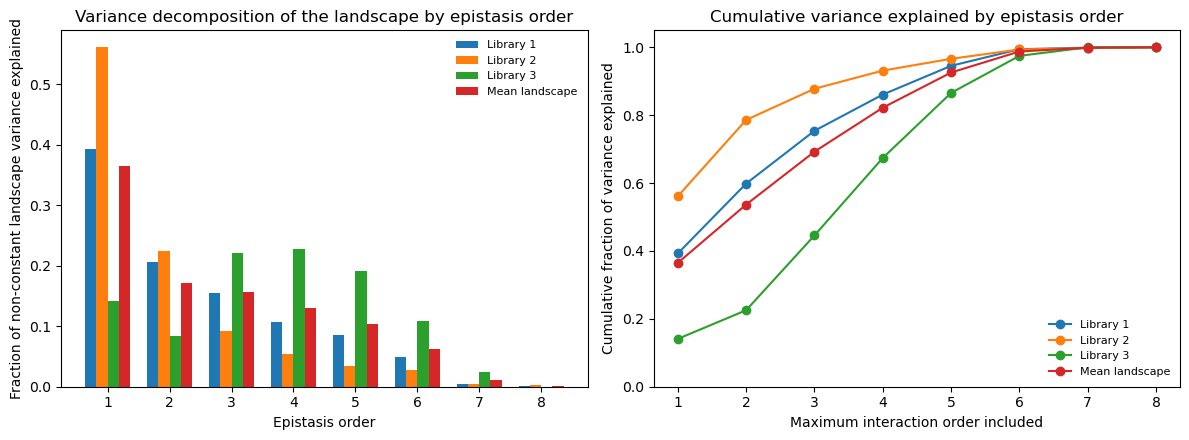

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

orders = sorted(walsh_variance_decomposition["term_order"].unique())
x = np.arange(len(orders))
bar_width = 0.18

plot_groups = [
    (1, "Library 1"),
    (2, "Library 2"),
    (3, "Library 3"),
    ("Mean landscape", "Mean landscape"),
]

# Left panel
for idx, (library_id, label) in enumerate(plot_groups):
    if library_id == "Mean landscape":
        sub = walsh_variance_with_mean[
            walsh_variance_with_mean["library_id"] == "Mean landscape"
        ].sort_values("term_order")
    else:
        sub = walsh_variance_decomposition[
            walsh_variance_decomposition["library_id"] == library_id
        ].sort_values("term_order")

    axes[0].bar(
        x + (idx - 1.5) * bar_width,
        sub["fraction_of_variance"],
        width=bar_width,
        label=label
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(orders)
axes[0].set_xlabel("Epistasis order")
axes[0].set_ylabel("Fraction of non-constant landscape variance explained")
axes[0].set_title("Variance decomposition of the landscape by epistasis order")
axes[0].legend(frameon=False, fontsize=8)

# Right panel
for library_id, label in plot_groups:
    if library_id == "Mean landscape":
        sub = walsh_variance_with_mean[
            walsh_variance_with_mean["library_id"] == "Mean landscape"
        ].sort_values("term_order")
    else:
        sub = walsh_variance_decomposition[
            walsh_variance_decomposition["library_id"] == library_id
        ].sort_values("term_order")

    axes[1].plot(
        sub["term_order"],
        sub["cumulative_fraction"],
        marker="o",
        label=label
    )

axes[1].set_xlabel("Maximum interaction order included")
axes[1].set_ylabel("Cumulative fraction of variance explained")
axes[1].set_title("Cumulative variance explained by epistasis order")
axes[1].set_xticks(orders)
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_16_variance_decomposition_by_order.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Exploratory regression-coefficient power by interaction order

The dissertation-facing Figure 3.16 is generated above using an orthogonal Walsh-style decomposition of the binary landscape. That decomposition estimates the fraction of non-constant landscape variance associated with each interaction order.

The following exploratory section uses a different parameterization: a full 0/1-coded interaction regression model. Squared fitted coefficients are grouped by interaction order and normalized by the total squared coefficient magnitude.

This representation is not used as the dissertation Figure 3.16 reproduction, because it is parameterization-dependent rather than an orthogonal variance decomposition. It is retained as an exploratory comparison because it provides a visually cleaner view of how fitted interaction coefficient magnitudes are distributed across orders.

In [16]:
def add_binary_interaction_terms(
    df: pd.DataFrame,
    base_cols: list[str],
    max_order: int = 8
) -> tuple[pd.DataFrame, list[str]]:
    """
    Add 0/1-coded interaction terms up to max_order.

    Main-effect columns are already present in df. Higher-order interaction
    terms are products of the binary mutation indicators.
    """
    out = df.copy()
    feature_cols = list(base_cols)

    interaction_series = []

    for order in range(2, max_order + 1):
        for combo in combinations(base_cols, order):
            term_name = "__x__".join(combo)
            term_values = df[list(combo)].prod(axis=1).rename(term_name)
            interaction_series.append(term_values)
            feature_cols.append(term_name)

    if interaction_series:
        interaction_df = pd.concat(interaction_series, axis=1)
        out = pd.concat(
            [
                out.reset_index(drop=True),
                interaction_df.reset_index(drop=True)
            ],
            axis=1
        )

    return out, feature_cols


def binary_term_order(term: str) -> int:
    return term.count("__x__") + 1

In [17]:
from sklearn.linear_model import LinearRegression

regression_power_rows = []
regression_coefficient_rows = []

for library_id, lib_df in epistasis_input.groupby("library_id"):
    lib_df = lib_df.sort_values("wo").reset_index(drop=True)

    design_df, feature_cols = add_binary_interaction_terms(
        lib_df,
        binary_cols,
        max_order=8
    )

    X = design_df[feature_cols].values
    y = design_df[EPISTASIS_RESPONSE].values

    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)

    coef_df = pd.DataFrame({
        "library_id": library_id,
        "response_col": EPISTASIS_RESPONSE,
        "term": feature_cols,
        "coefficient": model.coef_,
    })

    coef_df["term_order"] = coef_df["term"].apply(binary_term_order)
    coef_df["coefficient_squared"] = coef_df["coefficient"] ** 2

    regression_coefficient_rows.append(coef_df)

    order_summary = (
        coef_df
        .groupby("term_order", as_index=False)
        .agg(
            sum_coefficient_squared=("coefficient_squared", "sum"),
            n_terms=("term", "size")
        )
    )

    total_coefficient_power = order_summary["sum_coefficient_squared"].sum()

    order_summary["fraction_of_coefficient_power"] = (
        order_summary["sum_coefficient_squared"] / total_coefficient_power
    )

    order_summary["library_id"] = library_id
    order_summary["response_col"] = EPISTASIS_RESPONSE

    regression_power_rows.append(order_summary)

exploratory_regression_coefficients = pd.concat(
    regression_coefficient_rows,
    ignore_index=True
)

exploratory_regression_power = pd.concat(
    regression_power_rows,
    ignore_index=True
).sort_values(["library_id", "term_order"]).reset_index(drop=True)

exploratory_regression_power["cumulative_fraction"] = (
    exploratory_regression_power
    .groupby("library_id")["fraction_of_coefficient_power"]
    .cumsum()
)

exploratory_regression_coefficients.to_csv(
    CHECKPOINT_DIR / "exploratory_regression_interaction_coefficients.csv",
    index=False
)

exploratory_regression_power.to_csv(
    CHECKPOINT_DIR / "exploratory_regression_coefficient_power_by_order.csv",
    index=False
)

exploratory_regression_power.head(20)

,term_order,sum_coefficient_squared,n_terms,fraction_of_coefficient_power,library_id,response_col,cumulative_fraction
0,1,8.206504,8,0.001703,1,ddelta,0.001703
1,2,54.749790,28,0.011359,1,ddelta,0.013062
2,3,248.634067,56,0.051586,1,ddelta,0.064648
3,4,836.133310,70,0.173479,1,ddelta,0.238127
4,5,1601.703611,56,0.332318,1,ddelta,0.570446
5,6,1404.209372,28,0.291343,1,ddelta,0.861788
6,7,490.590897,8,0.101787,1,ddelta,0.963575
7,8,175.559513,1,0.036425,1,ddelta,1.000000
8,1,6.847385,8,0.001371,2,ddelta,0.001371
9,2,62.747810,28,0.012563,2,ddelta,0.013934


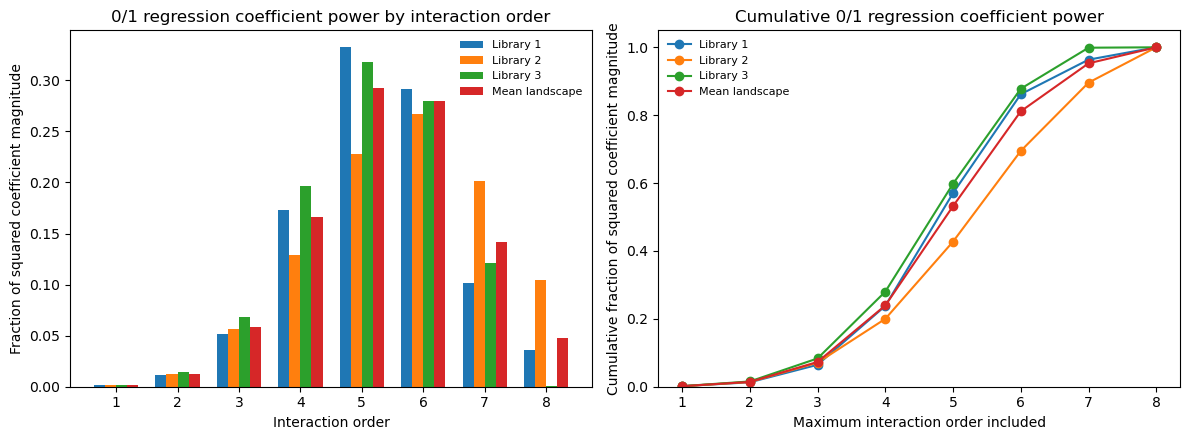

,term_order,sum_coefficient_squared,n_terms,fraction_of_coefficient_power,library_id,response_col,cumulative_fraction
0,1,8.206504,8,0.001703,1,ddelta,0.001703
1,2,54.749790,28,0.011359,1,ddelta,0.013062
2,3,248.634067,56,0.051586,1,ddelta,0.064648
3,4,836.133310,70,0.173479,1,ddelta,0.238127
4,5,1601.703611,56,0.332318,1,ddelta,0.570446


In [18]:
exploratory_mean_power = (
    exploratory_regression_power
    .groupby("term_order", as_index=False)
    .agg(
        fraction_of_coefficient_power=("fraction_of_coefficient_power", "mean"),
        cumulative_fraction=("cumulative_fraction", "mean"),
        n_terms=("n_terms", "first")
    )
)

exploratory_mean_power["library_id"] = "Mean landscape"
exploratory_mean_power["response_col"] = EPISTASIS_RESPONSE

exploratory_regression_power_with_mean = pd.concat(
    [
        exploratory_regression_power,
        exploratory_mean_power
    ],
    ignore_index=True
)

exploratory_regression_power_with_mean.to_csv(
    CHECKPOINT_DIR / "exploratory_regression_coefficient_power_by_order_with_mean.csv",
    index=False
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

orders = sorted(exploratory_regression_power["term_order"].unique())
x = np.arange(len(orders))
bar_width = 0.18

plot_groups = [
    (1, "Library 1"),
    (2, "Library 2"),
    (3, "Library 3"),
    ("Mean landscape", "Mean landscape"),
]

# Left panel: coefficient power by order
for idx, (library_id, label) in enumerate(plot_groups):
    if library_id == "Mean landscape":
        sub = exploratory_regression_power_with_mean[
            exploratory_regression_power_with_mean["library_id"] == "Mean landscape"
        ].sort_values("term_order")
    else:
        sub = exploratory_regression_power[
            exploratory_regression_power["library_id"] == library_id
        ].sort_values("term_order")

    axes[0].bar(
        x + (idx - 1.5) * bar_width,
        sub["fraction_of_coefficient_power"],
        width=bar_width,
        label=label
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(orders)
axes[0].set_xlabel("Interaction order")
axes[0].set_ylabel("Fraction of squared coefficient magnitude")
axes[0].set_title("0/1 regression coefficient power by interaction order")
axes[0].legend(frameon=False, fontsize=8)

# Right panel: cumulative coefficient power
for library_id, label in plot_groups:
    if library_id == "Mean landscape":
        sub = exploratory_regression_power_with_mean[
            exploratory_regression_power_with_mean["library_id"] == "Mean landscape"
        ].sort_values("term_order")
    else:
        sub = exploratory_regression_power[
            exploratory_regression_power["library_id"] == library_id
        ].sort_values("term_order")

    axes[1].plot(
        sub["term_order"],
        sub["cumulative_fraction"],
        marker="o",
        label=label
    )

axes[1].set_xlabel("Maximum interaction order included")
axes[1].set_ylabel("Cumulative fraction of squared coefficient magnitude")
axes[1].set_title("Cumulative 0/1 regression coefficient power")
axes[1].set_xticks(orders)
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "exploratory_regression_coefficient_power_by_order.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

exploratory_regression_power_with_mean.head()

## Figure 3.12-style pairwise epistasis heatmaps

This section summarizes background-dependent pairwise epistasis values for each residue pair and library.

For each library, heatmaps are generated for signed epistasis and epistasis magnitude using mean, median, and mean-minus-median summary statistics.

In [19]:
pairwise_heatmap_summary = pairwise_epistasis_summary.copy()

pairwise_heatmap_summary["delta_mean_minus_median_epsilon"] = (
    pairwise_heatmap_summary["mean_epsilon"] -
    pairwise_heatmap_summary["median_epsilon"]
)

pairwise_heatmap_summary["delta_mean_minus_median_abs_epsilon"] = (
    pairwise_heatmap_summary["mean_abs_epsilon"] -
    pairwise_heatmap_summary["median_abs_epsilon"]
)

pairwise_heatmap_summary.to_csv(
    CHECKPOINT_DIR / "pairwise_epistasis_heatmap_summary.csv",
    index=False
)

pairwise_heatmap_summary.head()

,library_id,residue_pair,mean_epsilon,median_epsilon,sd_epsilon,mean_abs_epsilon,median_abs_epsilon,max_abs_epsilon,n_backgrounds,delta_mean_minus_median_epsilon,delta_mean_minus_median_abs_epsilon
0,1,477-478,0.292380,0.116780,2.227777,1.673945,1.432260,6.734947,64,0.175601,0.241685
1,1,477-484,-0.537754,-0.816608,2.129409,1.799958,1.600681,6.723764,64,0.278854,0.199278
2,1,477-493,0.487628,0.525392,2.347925,1.838291,1.399003,5.745340,64,-0.037765,0.439288
3,1,477-496,0.299587,0.349610,2.233081,1.772158,1.486637,5.496868,64,-0.050023,0.285521
4,1,477-498,-0.504122,-0.325924,2.353139,1.760879,1.333022,7.409489,64,-0.178198,0.427856


In [20]:
import matplotlib as mpl

def pairwise_summary_to_matrix(
    df: pd.DataFrame,
    value_col: str,
    library_id: int
) -> pd.DataFrame:
    """
    Convert pairwise summary table into a symmetric site-by-site matrix.
    """
    sub = df[df["library_id"] == library_id].copy()

    matrix = pd.DataFrame(
        np.nan,
        index=SITE_LABELS,
        columns=SITE_LABELS,
        dtype=float
    )

    for _, row in sub.iterrows():
        i = row["residue_pair"].split("-")[0]
        j = row["residue_pair"].split("-")[1]

        matrix.loc[i, j] = row[value_col]
        matrix.loc[j, i] = row[value_col]

    return matrix

def plot_pairwise_heatmap(
    matrix: pd.DataFrame,
    ax,
    title: str,
    cmap: str,
    vmin: float,
    vmax: float,
    show_values: bool = True
):
    """
    Plot one symmetric pairwise heatmap with annotation colors chosen
    to contrast with the background color.
    """
    im = ax.imshow(matrix.values, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(SITE_LABELS)))
    ax.set_yticks(range(len(SITE_LABELS)))
    ax.set_xticklabels(SITE_LABELS, rotation=90, fontsize=7)
    ax.set_yticklabels(SITE_LABELS, fontsize=7)
    ax.set_title(title, fontsize=9)

    # Hide diagonal cells visually.
    for i in range(len(SITE_LABELS)):
        ax.add_patch(
            plt.Rectangle(
                (i - 0.5, i - 0.5),
                1,
                1,
                fill=True,
                color="white",
                ec="white"
            )
        )

    if show_values:
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = plt.get_cmap(cmap)

        for i in range(len(SITE_LABELS)):
            for j in range(len(SITE_LABELS)):
                value = matrix.iloc[i, j]

                if pd.notna(value) and i != j:
                    rgba = cmap_obj(norm(value))

                    # Perceived luminance
                    luminance = (
                        0.299 * rgba[0] +
                        0.587 * rgba[1] +
                        0.114 * rgba[2]
                    )

                    text_color = "black" if luminance > 0.55 else "white"

                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=5,
                        color=text_color
                    )

    return im

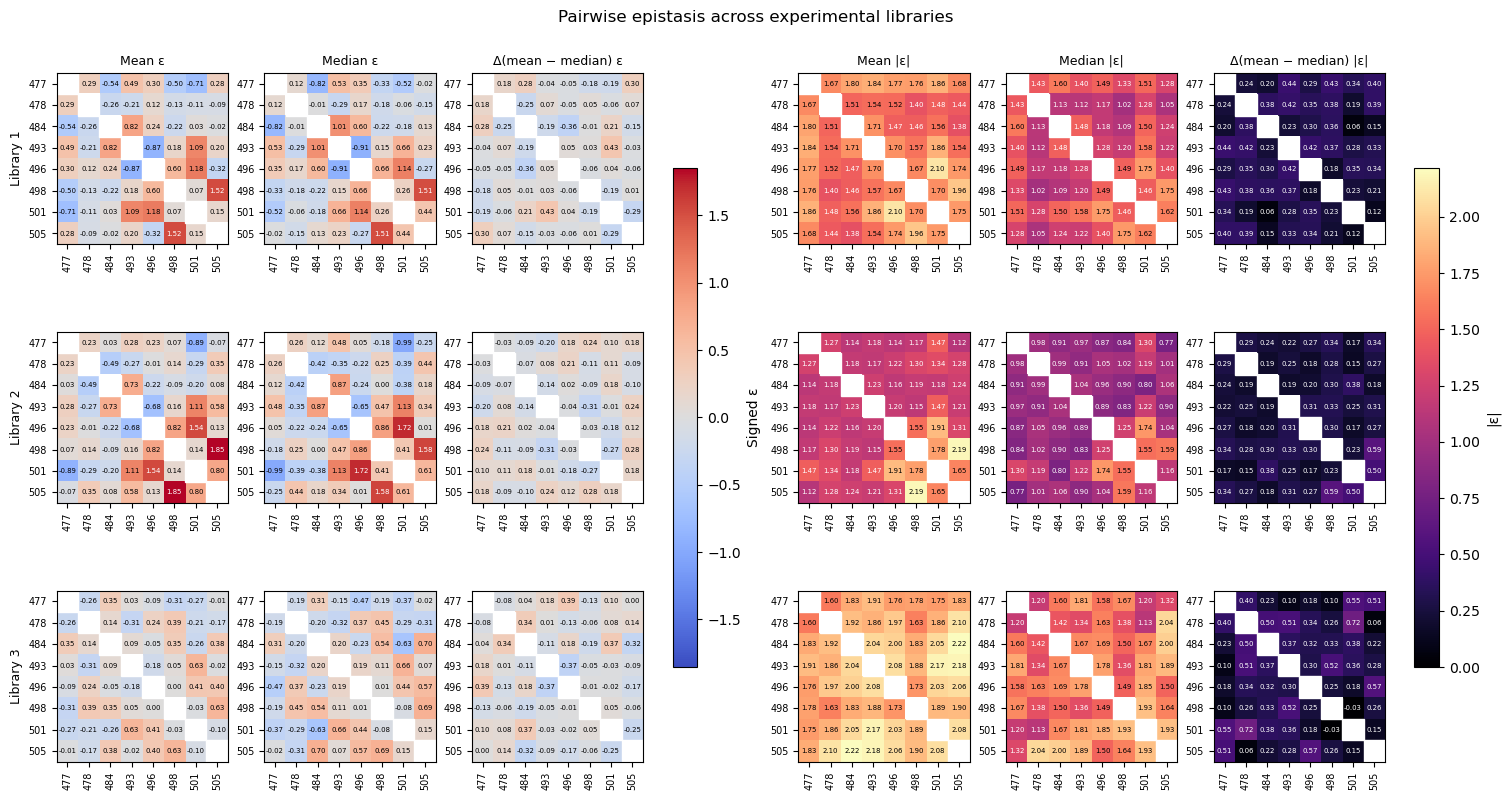

In [21]:
signed_cols = [
    ("mean_epsilon", "Mean ε"),
    ("median_epsilon", "Median ε"),
    ("delta_mean_minus_median_epsilon", "Δ(mean − median) ε"),
]

magnitude_cols = [
    ("mean_abs_epsilon", "Mean |ε|"),
    ("median_abs_epsilon", "Median |ε|"),
    ("delta_mean_minus_median_abs_epsilon", "Δ(mean − median) |ε|"),
]

heatmap_specs = signed_cols + magnitude_cols

# Shared scales for signed and magnitude panels.
signed_values = pairwise_heatmap_summary[
    [col for col, _ in signed_cols]
].values.flatten()
signed_limit = np.nanmax(np.abs(signed_values))

magnitude_values = pairwise_heatmap_summary[
    [col for col, _ in magnitude_cols]
].values.flatten()
magnitude_max = np.nanmax(magnitude_values)

fig, axes = plt.subplots(
    3,
    6,
    figsize=(15, 8),
    constrained_layout=True
)

last_signed_im = None
last_magnitude_im = None


for row_idx, library_id in enumerate(sorted(pairwise_heatmap_summary["library_id"].unique())):
    for col_idx, (value_col, title) in enumerate(heatmap_specs):
        ax = axes[row_idx, col_idx]

        matrix = pairwise_summary_to_matrix(
            pairwise_heatmap_summary,
            value_col=value_col,
            library_id=library_id
        )
        
        if value_col in [col for col, _ in signed_cols]:
            im = plot_pairwise_heatmap(
                matrix,
                ax=ax,
                title=title if row_idx == 0 else "",
                cmap="coolwarm",
                vmin=-signed_limit,
                vmax=signed_limit,
                show_values=True
            )
            last_signed_im = im
        else:
            im = plot_pairwise_heatmap(
                matrix,
                ax=ax,
                title=title if row_idx == 0 else "",
                cmap="magma",
                vmin=0,
                vmax=magnitude_max,
                show_values=True
            )
            last_magnitude_im = im

        if col_idx == 0:
            ax.set_ylabel(f"Library {library_id}", fontsize=9)

fig.suptitle("Pairwise epistasis across experimental libraries", fontsize=12)

# Add colorbars.
fig.colorbar(
    last_signed_im,
    ax=axes[:, :3],
    shrink=0.65,
    label="Signed ε"
)

fig.colorbar(
    last_magnitude_im,
    ax=axes[:, 3:],
    shrink=0.65,
    label="|ε|"
)

fig.savefig(
    FIGURE_DIR / "figure_3_12_pairwise_epistasis_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

For the magnitude panels, `Δ(mean − median) |ε|` is calculated as `mean(|ε|) − median(|ε|)`. Values are nearly all nonnegative in this dataset, so the panel is displayed using the same magnitude-oriented color scale for visual consistency.

## Table 3.7-style cross-library correlation of pairwise epistasis estimates

This section compares pairwise epistasis estimates between experimental libraries.

For each library pair, Pearson correlations are calculated across all residue pairs using:

- median signed pairwise epistasis, `median_epsilon`
- median pairwise epistasis magnitude, `median_abs_epsilon`

In [22]:
# Table 3.7-style cross-library correlation of pairwise epistasis estimates.

table_3_7_rows = []

pairwise_metric_specs = [
    ("median_epsilon", "Median ε"),
    ("median_abs_epsilon", "Median |ε|"),
]

library_pairs = [
    (1, 2),
    (1, 3),
    (2, 3),
]

for lib_a, lib_b in library_pairs:
    lib_a_df = (
        pairwise_epistasis_summary
        .query("library_id == @lib_a")
        [["residue_pair", "median_epsilon", "median_abs_epsilon"]]
        .rename(columns={
            "median_epsilon": "median_epsilon_a",
            "median_abs_epsilon": "median_abs_epsilon_a",
        })
    )

    lib_b_df = (
        pairwise_epistasis_summary
        .query("library_id == @lib_b")
        [["residue_pair", "median_epsilon", "median_abs_epsilon"]]
        .rename(columns={
            "median_epsilon": "median_epsilon_b",
            "median_abs_epsilon": "median_abs_epsilon_b",
        })
    )

    merged = lib_a_df.merge(
        lib_b_df,
        on="residue_pair",
        how="inner"
    )

    assert merged.shape[0] == 28, (
        f"Expected 28 residue pairs for Library {lib_a} vs Library {lib_b}."
    )

    for metric_col, metric_label in pairwise_metric_specs:
        x = merged[f"{metric_col}_a"]
        y = merged[f"{metric_col}_b"]

        r_value, p_value = pearsonr(x, y)

        table_3_7_rows.append({
            "Comparison": f"Library {lib_a} vs Library {lib_b}",
            "Metric": metric_label,
            "Pearson r": r_value,
            "p-value": p_value,
            "n_pairs": merged.shape[0],
        })

table_3_7 = pd.DataFrame(table_3_7_rows)

table_3_7.to_csv(
    CHECKPOINT_DIR / "table_3_7_pairwise_epistasis_cross_library_correlations.csv",
    index=False
)

table_3_7

,Comparison,Metric,Pearson r,p-value,n_pairs
0,Library 1 vs Library 2,Median ε,0.801408,2.982714e-07,28
1,Library 1 vs Library 2,Median |ε|,0.576330,1.328046e-03,28
2,Library 1 vs Library 3,Median ε,0.261588,1.787418e-01,28
3,Library 1 vs Library 3,Median |ε|,0.163272,4.064507e-01,28
4,Library 2 vs Library 3,Median ε,0.513312,5.212810e-03,28
5,Library 2 vs Library 3,Median |ε|,0.189063,3.352759e-01,28


In [23]:
def significance_stars(p_value: float) -> str:
    """
    Return dissertation-style significance stars.
    """
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    return ""


def format_p_value_with_stars(p_value: float) -> str:
    """
    Format p-values with compact display and significance stars.
    """
    stars = significance_stars(p_value)

    if p_value < 0.001:
        return f"<0.001{stars}"
    elif p_value < 0.01:
        return f"{p_value:.3f}{stars}"
    elif p_value < 0.05:
        return f"{p_value:.3f}{stars}"
    else:
        return f"{p_value:.2f}"


table_3_7_display = table_3_7.copy()

table_3_7_display["Pearson r"] = table_3_7_display["Pearson r"].map(
    lambda x: f"{x:.2f}"
)

table_3_7_display["p-value"] = table_3_7_display["p-value"].map(
    format_p_value_with_stars
)

table_3_7_display = table_3_7_display[
    ["Comparison", "Metric", "Pearson r", "p-value"]
]

table_3_7_display.to_csv(
    CHECKPOINT_DIR / "table_3_7_pairwise_epistasis_cross_library_correlations_display.csv",
    index=False
)

table_3_7_display

,Comparison,Metric,Pearson r,p-value
0,Library 1 vs Library 2,Median ε,0.80,<0.001***
1,Library 1 vs Library 2,Median |ε|,0.58,0.001**
2,Library 1 vs Library 3,Median ε,0.26,0.18
3,Library 1 vs Library 3,Median |ε|,0.16,0.41
4,Library 2 vs Library 3,Median ε,0.51,0.005**
5,Library 2 vs Library 3,Median |ε|,0.19,0.34


Significance levels: *** p < 0.001, ** p < 0.01, * p < 0.05.

## Figure 3.14-style cross-library comparison of signed pairwise epistasis

This section compares signed pairwise epistasis estimates across experimental libraries.

For each residue pair, the median background-dependent pairwise epistasis value is shown for each library. Residue pairs are ordered by the cross-library mean of median signed epistasis.

In [24]:
pairwise_cross_library = pairwise_epistasis_summary[
    [
        "library_id",
        "residue_pair",
        "median_epsilon",
        "median_abs_epsilon",
        "mean_epsilon",
        "mean_abs_epsilon",
    ]
].copy()

pairwise_cross_library_wide = (
    pairwise_cross_library
    .pivot(
        index="residue_pair",
        columns="library_id",
        values="median_epsilon"
    )
    .rename(columns=lambda x: f"Library {x}")
)

pairwise_cross_library_wide["cross_library_mean"] = (
    pairwise_cross_library_wide[["Library 1", "Library 2", "Library 3"]]
    .mean(axis=1)
)

pairwise_cross_library_wide["cross_library_sd"] = (
    pairwise_cross_library_wide[["Library 1", "Library 2", "Library 3"]]
    .std(axis=1)
)

pairwise_cross_library_wide["all_same_sign"] = (
    np.sign(pairwise_cross_library_wide["Library 1"]) ==
    np.sign(pairwise_cross_library_wide["Library 2"])
) & (
    np.sign(pairwise_cross_library_wide["Library 1"]) ==
    np.sign(pairwise_cross_library_wide["Library 3"])
)

pairwise_cross_library_wide = (
    pairwise_cross_library_wide
    .sort_values("cross_library_mean", ascending=False)
)

pairwise_cross_library_wide.to_csv(
    CHECKPOINT_DIR / "figure_3_14_pairwise_epistasis_cross_library_values.csv"
)

pairwise_cross_library_wide.head()

library_id,Library 1,Library 2,Library 3,cross_library_mean,cross_library_sd,all_same_sign
residue_pair,,,,,,
498-505,1.511955,1.575175,0.687947,1.258359,0.495002,True
496-501,1.141585,1.718910,0.435146,1.098547,0.642963,True
493-501,0.660671,1.129008,0.661116,0.816932,0.270267,True
484-493,1.011203,0.867534,0.197836,0.692191,0.434109,True
496-498,0.659510,0.859369,0.011189,0.510023,0.443410,True


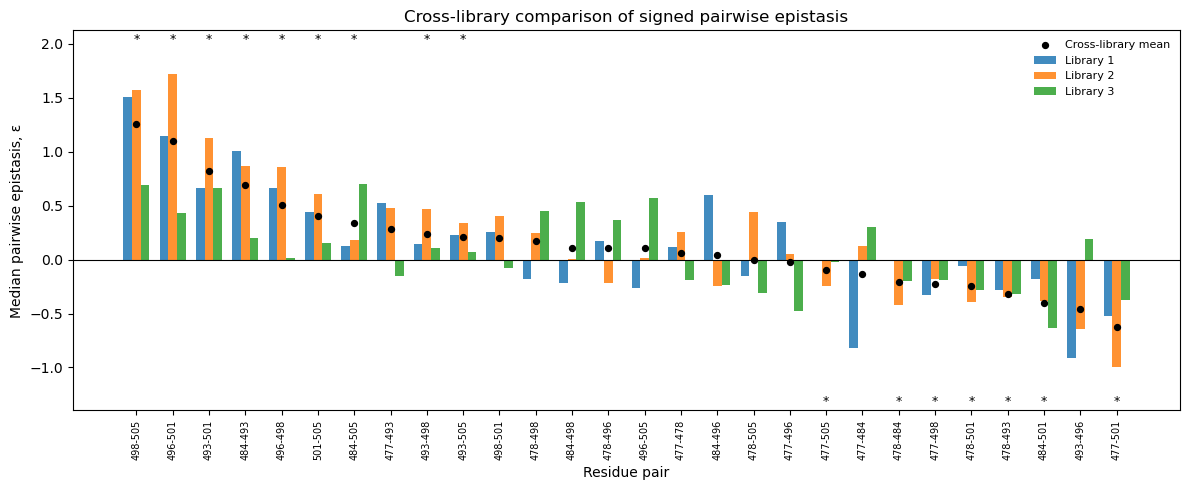

In [25]:
plot_df = pairwise_cross_library_wide.copy()

x = np.arange(plot_df.shape[0])
bar_width = 0.24

fig, ax = plt.subplots(figsize=(12, 5))

library_cols = ["Library 1", "Library 2", "Library 3"]

for idx, col in enumerate(library_cols):
    ax.bar(
        x + (idx - 1) * bar_width,
        plot_df[col],
        width=bar_width,
        label=col,
        alpha=0.85
    )

# Cross-library mean marker
ax.scatter(
    x,
    plot_df["cross_library_mean"],
    color="black",
    s=18,
    zorder=3,
    label="Cross-library mean"
)

ax.axhline(0, color="black", linewidth=0.8)

# Set axis limits first so annotation rows can be placed safely inside.
y_min = min(
    plot_df[library_cols].min().min(),
    plot_df["cross_library_mean"].min()
)
y_max = max(
    plot_df[library_cols].max().max(),
    plot_df["cross_library_mean"].max()
)

padding = 0.15 * (y_max - y_min)
ax.set_ylim(y_min - padding, y_max + padding)

ylim = ax.get_ylim()
star_y_top = ylim[1] - 0.04 * (ylim[1] - ylim[0])
star_y_bottom = ylim[0] + 0.04 * (ylim[1] - ylim[0])

# Mark pairs with same sign across all libraries.
for idx, (_, row) in enumerate(plot_df.iterrows()):
    if row["all_same_sign"]:
        if row["cross_library_mean"] >= 0:
            star_y = star_y_top
            va = "bottom"
        else:
            star_y = star_y_bottom
            va = "top"

        ax.text(
            idx,
            star_y,
            "*",
            ha="center",
            va=va,
            fontsize=9,
            color="black",
            clip_on=True
        )

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=90, fontsize=7)
ax.set_ylabel("Median pairwise epistasis, ε")
ax.set_xlabel("Residue pair")
ax.set_title("Cross-library comparison of signed pairwise epistasis")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_14_pairwise_epistasis_cross_library_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
pairwise_same_sign_summary = (
    pairwise_cross_library_wide
    .reset_index()
    .groupby("all_same_sign", as_index=False)
    .agg(n_pairs=("residue_pair", "size"))
)

pairwise_same_sign_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_14_pairwise_same_sign_summary.csv",
    index=False
)

pairwise_same_sign_summary

,all_same_sign,n_pairs
0,False,12
1,True,16


## Figure 3.13-style pairwise epistasis distributions across genetic backgrounds

This section visualizes the distribution of background-dependent pairwise epistasis values for each residue pair.

Each residue pair has 64 background-specific pairwise epistasis values per library. Residue pairs are ordered by cross-library median epistasis magnitude.

In [27]:
# Order residue pairs by cross-library median epistasis magnitude.
# This gives a stable top-to-bottom order for the ridgeline plot.

pairwise_ridgeline_order = (
    pairwise_epistasis_summary
    .groupby("residue_pair", as_index=False)
    .agg(
        cross_library_median_abs_epsilon=("median_abs_epsilon", "mean"),
        cross_library_mean_abs_epsilon=("mean_abs_epsilon", "mean"),
    )
    .sort_values("cross_library_median_abs_epsilon", ascending=False)
)

pairwise_ridgeline_order.to_csv(
    CHECKPOINT_DIR / "figure_3_13_pairwise_ridgeline_order.csv",
    index=False
)

pair_order = pairwise_ridgeline_order["residue_pair"].tolist()

pairwise_ridgeline_order.head()

,residue_pair,cross_library_median_abs_epsilon,cross_library_mean_abs_epsilon
23,496-501,1.777451,2.012674
26,498-505,1.660168,2.015244
25,498-501,1.645061,1.789034
27,501-505,1.569678,1.825814
20,493-501,1.535467,1.832193


In [28]:
from scipy.stats import gaussian_kde

def safe_kde(values: np.ndarray, x_grid: np.ndarray) -> np.ndarray:
    """
    Compute KDE safely. If values have too little variation, return zeros.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2 or np.std(values) == 0:
        return np.zeros_like(x_grid)

    kde = gaussian_kde(values)
    density = kde(x_grid)

    if density.max() > 0:
        density = density / density.max()

    return density

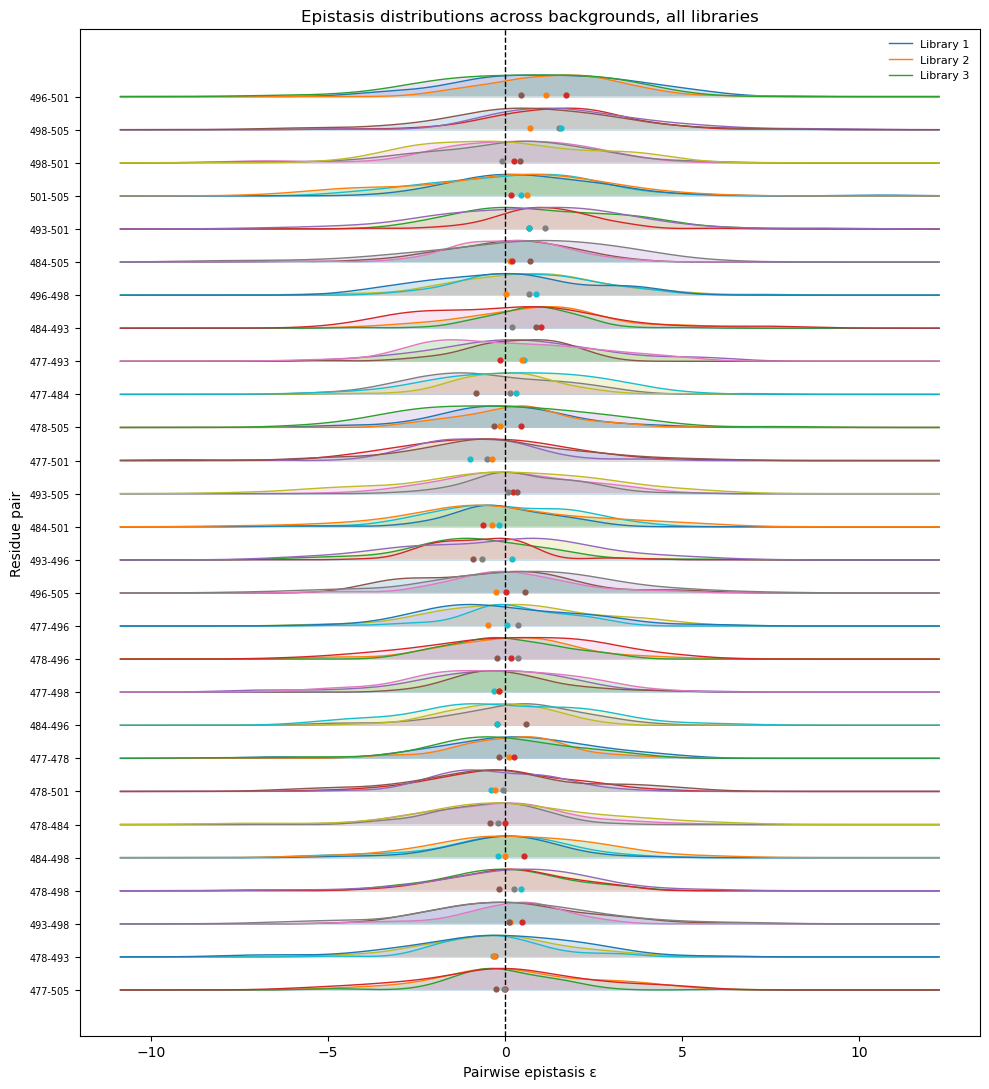

In [29]:
# Figure 3.13-style ridgeline distributions for pairwise epistasis.

plot_df = pairwise_epistasis.copy()

x_min = plot_df["epsilon"].min()
x_max = plot_df["epsilon"].max()
x_padding = 0.08 * (x_max - x_min)

x_grid = np.linspace(
    x_min - x_padding,
    x_max + x_padding,
    400
)

library_ids = sorted(plot_df["library_id"].unique())

fig, ax = plt.subplots(figsize=(10, 11))

ridge_spacing = 1.0
ridge_height = 0.65

for pair_idx, residue_pair in enumerate(pair_order):
    y_base = len(pair_order) - pair_idx

    for library_id in library_ids:
        sub = plot_df[
            (plot_df["residue_pair"] == residue_pair) &
            (plot_df["library_id"] == library_id)
        ]

        values = sub["epsilon"].dropna().values
        density = safe_kde(values, x_grid)

        y = y_base + density * ridge_height

        ax.plot(
            x_grid,
            y,
            linewidth=1.0,
            label=f"Library {library_id}" if pair_idx == 0 else None
        )

        ax.fill_between(
            x_grid,
            y_base,
            y,
            alpha=0.18
        )

        # Mark the median of each library distribution.
        median_value = np.median(values)
        ax.scatter(
            median_value,
            y_base + 0.04,
            s=12,
            zorder=3
        )

    # Baseline for each residue pair.
    ax.hlines(
        y_base,
        x_grid.min(),
        x_grid.max(),
        linewidth=0.4,
        alpha=0.4
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

ax.set_yticks([len(pair_order) - i for i in range(len(pair_order))])
ax.set_yticklabels(pair_order, fontsize=7)

ax.set_xlabel("Pairwise epistasis ε")
ax.set_ylabel("Residue pair")
ax.set_title("Epistasis distributions across backgrounds, all libraries")
ax.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_13_pairwise_epistasis_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
figure_3_13_distribution_summary = (
    pairwise_epistasis
    .groupby(["library_id", "residue_pair"], as_index=False)
    .agg(
        n_backgrounds=("epsilon", "size"),
        mean_epsilon=("epsilon", "mean"),
        median_epsilon=("epsilon", "median"),
        sd_epsilon=("epsilon", "std"),
        min_epsilon=("epsilon", "min"),
        max_epsilon=("epsilon", "max"),
        mean_abs_epsilon=("abs_epsilon", "mean"),
        median_abs_epsilon=("abs_epsilon", "median"),
    )
)

figure_3_13_distribution_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_13_pairwise_epistasis_distribution_summary.csv",
    index=False
)

figure_3_13_distribution_summary.head()

,library_id,residue_pair,n_backgrounds,mean_epsilon,median_epsilon,sd_epsilon,min_epsilon,max_epsilon,mean_abs_epsilon,median_abs_epsilon
0,1,477-478,64,0.292380,0.116780,2.227777,-6.734947,4.812829,1.673945,1.432260
1,1,477-484,64,-0.537754,-0.816608,2.129409,-5.165711,6.723764,1.799958,1.600681
2,1,477-493,64,0.487628,0.525392,2.347925,-4.744256,5.745340,1.838291,1.399003
3,1,477-496,64,0.299587,0.349610,2.233081,-5.496868,5.381516,1.772158,1.486637
4,1,477-498,64,-0.504122,-0.325924,2.353139,-7.409489,5.344684,1.760879,1.333022


## Figure 3.15-style pairwise epistatic interaction network

This section summarizes pairwise epistatic interactions as a network across the eight design sites.

Nodes represent residue positions, and edges connect residue pairs for which pairwise epistasis was quantified. Edge color indicates the direction of interaction based on the cross-library median signed epistasis. Edge thickness scales with cross-library median epistasis magnitude. Solid edges indicate complete sign agreement across libraries, and dashed edges indicate incomplete sign agreement.

In [31]:
pairwise_network_summary = (
    pairwise_epistasis_summary
    .groupby("residue_pair", as_index=False)
    .agg(
        cross_library_mean_epsilon=("median_epsilon", "mean"),
        cross_library_median_abs_epsilon=("median_abs_epsilon", "mean"),
        cross_library_sd_epsilon=("median_epsilon", "std"),
    )
)

# Add per-library values so we can check sign agreement explicitly.
pairwise_sign_wide = (
    pairwise_epistasis_summary
    .pivot(
        index="residue_pair",
        columns="library_id",
        values="median_epsilon"
    )
    .rename(columns=lambda x: f"Library {x}")
    .reset_index()
)

pairwise_network_summary = pairwise_network_summary.merge(
    pairwise_sign_wide,
    on="residue_pair",
    how="left"
)

pairwise_network_summary["all_same_sign"] = (
    np.sign(pairwise_network_summary["Library 1"]) ==
    np.sign(pairwise_network_summary["Library 2"])
) & (
    np.sign(pairwise_network_summary["Library 1"]) ==
    np.sign(pairwise_network_summary["Library 3"])
)

pairwise_network_summary["mean_abs_sign"] = np.sign(
    pairwise_network_summary["cross_library_mean_epsilon"]
)

pairwise_network_summary["edge_style"] = np.where(
    pairwise_network_summary["all_same_sign"],
    "solid",
    "dashed"
)

pairwise_network_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_15_pairwise_network_summary.csv",
    index=False
)

pairwise_network_summary.head()

,residue_pair,cross_library_mean_epsilon,cross_library_median_abs_epsilon,cross_library_sd_epsilon,Library 1,Library 2,Library 3,all_same_sign,mean_abs_sign,edge_style
0,477-478,0.063258,1.203676,0.226973,0.116780,0.258686,-0.185693,False,1.0,dashed
1,477-484,-0.129864,1.369438,0.601763,-0.816608,0.121832,0.305185,False,-1.0,dashed
2,477-493,0.284301,1.392337,0.376586,0.525392,0.477161,-0.149652,False,1.0,dashed
3,477-496,-0.024286,1.310730,0.417282,0.349610,0.051967,-0.474436,False,-1.0,dashed
4,477-498,-0.230455,1.280723,0.082828,-0.325924,-0.177762,-0.187678,True,-1.0,solid


In [32]:
import networkx as nx

G_pairwise = nx.Graph()

# Add nodes
for site in SITE_LABELS:
    G_pairwise.add_node(site)

# Add edges
for _, row in pairwise_network_summary.iterrows():
    site_a, site_b = row["residue_pair"].split("-")

    G_pairwise.add_edge(
        site_a,
        site_b,
        residue_pair=row["residue_pair"],
        mean_epsilon=row["cross_library_mean_epsilon"],
        median_abs_epsilon=row["cross_library_median_abs_epsilon"],
        sd_epsilon=row["cross_library_sd_epsilon"],
        all_same_sign=row["all_same_sign"],
        edge_style=row["edge_style"],
    )

print("Nodes:", G_pairwise.number_of_nodes())
print("Edges:", G_pairwise.number_of_edges())

Nodes: 8
Edges: 28


In [33]:
# Fixed node layout roughly matching the dissertation-style network.
# You can tweak this later if desired.

node_positions = {
    "477": (0.85, 0.85),
    "478": (1.75, 0.65),
    "484": (0.30, -0.10),
    "493": (-0.55, 0.20),
    "496": (1.05, 0.05),
    "498": (0.90, -0.95),
    "501": (1.95, -0.10),
    "505": (0.95, -1.65),
}

edge_values = np.array([
    abs(data["mean_epsilon"])
    for _, _, data in G_pairwise.edges(data=True)
])

magnitude_values = np.array([
    data["median_abs_epsilon"]
    for _, _, data in G_pairwise.edges(data=True)
])

edge_abs_limit = np.max(np.abs(edge_values)) if len(edge_values) else 1.0
edge_mag_min = np.min(magnitude_values) if len(magnitude_values) else 0.0
edge_mag_max = np.max(magnitude_values) if len(magnitude_values) else 1.0


def scale_linewidth(value, vmin, vmax, lw_min=0.8, lw_max=5.5):
    """
    Scale edge line width by epistasis magnitude.
    """
    if vmax == vmin:
        return (lw_min + lw_max) / 2
    return lw_min + (value - vmin) * (lw_max - lw_min) / (vmax - vmin)

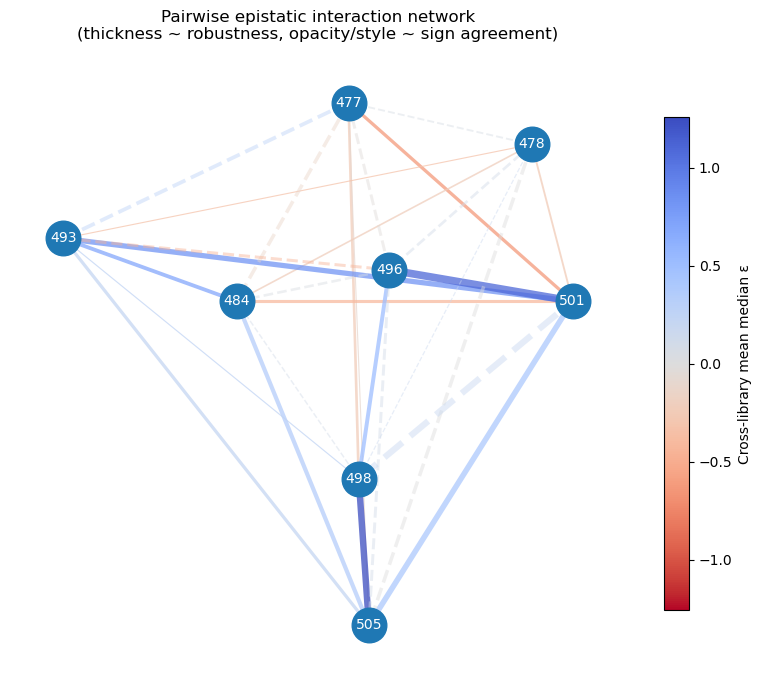

In [34]:
fig, ax = plt.subplots(figsize=(8, 7))

# Node drawing
nx.draw_networkx_nodes(
    G_pairwise,
    pos=node_positions,
    node_size=620,
    ax=ax
)

nx.draw_networkx_labels(
    G_pairwise,
    pos=node_positions,
    font_size=10,
    font_color="white",
    ax=ax
)

# Prepare edge groups
solid_edges = []
solid_widths = []
solid_colors = []

dashed_edges = []
dashed_widths = []
dashed_colors = []

cmap = plt.get_cmap("coolwarm_r")
norm = mpl.colors.Normalize(vmin=-edge_abs_limit, vmax=edge_abs_limit)

for u, v, data in G_pairwise.edges(data=True):
    edge_tuple = (u, v)

    color = cmap(norm(data["mean_epsilon"]))
    width = scale_linewidth(
        data["median_abs_epsilon"],
        edge_mag_min,
        edge_mag_max
    )

    if data["edge_style"] == "solid":
        solid_edges.append(edge_tuple)
        solid_widths.append(width)
        solid_colors.append(color)
    else:
        dashed_edges.append(edge_tuple)
        dashed_widths.append(width)
        dashed_colors.append(color)

# Draw solid edges
nx.draw_networkx_edges(
    G_pairwise,
    pos=node_positions,
    edgelist=solid_edges,
    width=solid_widths,
    edge_color=solid_colors,
    alpha=0.75,
    ax=ax
)

# Draw dashed edges
nx.draw_networkx_edges(
    G_pairwise,
    pos=node_positions,
    edgelist=dashed_edges,
    width=dashed_widths,
    edge_color=dashed_colors,
    alpha=0.45,
    style="dashed",
    ax=ax
)

# Add colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.78)
cbar.set_label("Cross-library mean median ε")

ax.set_title(
    "Pairwise epistatic interaction network\n"
    "(thickness ~ robustness, opacity/style ~ sign agreement)"
)
ax.axis("off")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_15_pairwise_epistatic_interaction_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 3.18-style cross-library comparison of third-order epistasis

This section compares third-order epistasis estimates across experimental libraries.

For each residue triplet, the median background-dependent third-order epistasis value is shown for each library. A selected set of high-magnitude triplets is retained based on cross-library mean absolute third-order epistasis magnitude, then plotted in descending order by cross-library mean signed third-order epistasis.

In [35]:
third_order_cross_library = third_order_epistasis_summary[
    [
        "library_id",
        "residue_triplet",
        "mean_epsilon_3",
        "median_epsilon_3",
        "mean_abs_epsilon_3",
        "median_abs_epsilon_3",
    ]
].copy()

third_order_cross_library_wide = (
    third_order_cross_library
    .pivot(
        index="residue_triplet",
        columns="library_id",
        values="median_epsilon_3"
    )
    .rename(columns=lambda x: f"Library {x}")
)

third_order_cross_library_wide["cross_library_mean"] = (
    third_order_cross_library_wide[["Library 1", "Library 2", "Library 3"]]
    .mean(axis=1)
)

third_order_cross_library_wide["cross_library_mean_abs"] = (
    third_order_cross_library_wide[["Library 1", "Library 2", "Library 3"]]
    .abs()
    .mean(axis=1)
)

third_order_cross_library_wide["cross_library_sd"] = (
    third_order_cross_library_wide[["Library 1", "Library 2", "Library 3"]]
    .std(axis=1)
)

third_order_cross_library_wide["all_same_sign"] = (
    np.sign(third_order_cross_library_wide["Library 1"]) ==
    np.sign(third_order_cross_library_wide["Library 2"])
) & (
    np.sign(third_order_cross_library_wide["Library 1"]) ==
    np.sign(third_order_cross_library_wide["Library 3"])
)

third_order_cross_library_wide = (
    third_order_cross_library_wide
    .sort_values("cross_library_mean_abs", ascending=False)
)

third_order_cross_library_wide.to_csv(
    CHECKPOINT_DIR / "figure_3_18_third_order_cross_library_values.csv"
)

third_order_cross_library_wide.head(15)

library_id,Library 1,Library 2,Library 3,cross_library_mean,cross_library_mean_abs,cross_library_sd,all_same_sign
residue_triplet,,,,,,,
496-498-501,-1.990934,-1.879411,-1.247749,-1.706031,1.706031,0.400782,True
498-501-505,-0.978989,-2.310652,-0.755243,-1.348295,1.348295,0.840901,True
484-496-505,-0.598378,-0.888270,-2.456043,-1.314230,1.314230,0.999406,True
478-496-505,0.635660,0.910964,-1.664863,-0.039413,1.070496,1.414395,False
496-498-505,0.746804,0.984232,-0.825627,0.301803,0.852221,0.983573,False
493-496-501,1.022905,-0.294708,-1.180335,-0.150713,0.832650,1.108656,False
484-498-501,0.777715,0.573141,1.112915,0.821257,0.821257,0.272509,True
477-493-498,-1.691102,0.605881,0.002893,-0.360776,0.766626,1.190892,False
478-493-498,1.015897,-0.811535,-0.414602,-0.070080,0.747345,0.961196,False


In [36]:
N_TOP_THIRD_ORDER_TRIPLETS = 12

third_order_top_triplets = (
    third_order_cross_library_wide
    .sort_values("cross_library_mean_abs", ascending=False)
    .head(N_TOP_THIRD_ORDER_TRIPLETS)
    .copy()
)

selected_third_order_triplets = third_order_top_triplets.index.tolist()

third_order_top_triplets.to_csv(
    CHECKPOINT_DIR / "figure_3_18_selected_third_order_triplets.csv"
)

selected_third_order_triplets

['496-498-501',
 '498-501-505',
 '484-496-505',
 '478-496-505',
 '496-498-505',
 '493-496-501',
 '484-498-501',
 '477-493-498',
 '478-493-498',
 '493-498-505',
 '477-501-505',
 '477-493-501']

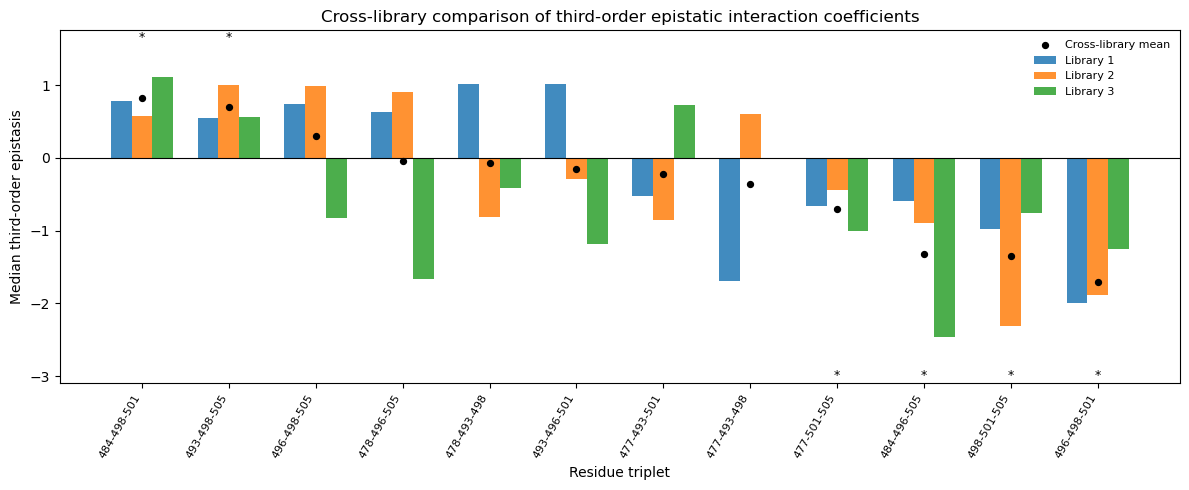

In [37]:
plot_df = third_order_top_triplets.copy()

# Explicit descending order by cross-library mean absolute magnitude.
plot_df = plot_df.sort_values("cross_library_mean", ascending=False)

x = np.arange(plot_df.shape[0])
bar_width = 0.24

fig, ax = plt.subplots(figsize=(12, 5))

library_cols = ["Library 1", "Library 2", "Library 3"]

for idx, col in enumerate(library_cols):
    ax.bar(
        x + (idx - 1) * bar_width,
        plot_df[col],
        width=bar_width,
        label=col,
        alpha=0.85
    )

# Cross-library mean marker
ax.scatter(
    x,
    plot_df["cross_library_mean"],
    color="black",
    s=18,
    zorder=3,
    label="Cross-library mean"
)

ax.axhline(0, color="black", linewidth=0.8)

# Set axis limits first so stars can be placed consistently inside the frame.
y_min = min(
    plot_df[library_cols].min().min(),
    plot_df["cross_library_mean"].min()
)
y_max = max(
    plot_df[library_cols].max().max(),
    plot_df["cross_library_mean"].max()
)

padding = 0.18 * (y_max - y_min)
ax.set_ylim(y_min - padding, y_max + padding)

ylim = ax.get_ylim()
star_y_top = ylim[1] - 0.04 * (ylim[1] - ylim[0])
star_y_bottom = ylim[0] + 0.04 * (ylim[1] - ylim[0])

# Mark triplets with same sign across all libraries.
for idx, (_, row) in enumerate(plot_df.iterrows()):
    if row["all_same_sign"]:
        if row["cross_library_mean"] >= 0:
            star_y = star_y_top
            va = "bottom"
        else:
            star_y = star_y_bottom
            va = "top"

        ax.text(
            idx,
            star_y,
            "*",
            ha="center",
            va=va,
            fontsize=9,
            color="black",
            clip_on=True
        )

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Median third-order epistasis")
ax.set_xlabel("Residue triplet")
ax.set_title("Cross-library comparison of third-order epistatic interaction coefficients")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_18_third_order_epistasis_cross_library_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
figure_3_18_selected_summary = (
    plot_df
    .reset_index()
    [
        [
            "residue_triplet",
            "Library 1",
            "Library 2",
            "Library 3",
            "cross_library_mean",
            "cross_library_mean_abs",
            "cross_library_sd",
            "all_same_sign",
        ]
    ]
)

figure_3_18_selected_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_18_selected_third_order_summary.csv",
    index=False
)

figure_3_18_selected_summary

library_id,residue_triplet,Library 1,Library 2,Library 3,cross_library_mean,cross_library_mean_abs,cross_library_sd,all_same_sign
0,484-498-501,0.777715,0.573141,1.112915,0.821257,0.821257,0.272509,True
1,493-498-505,0.553377,0.998333,0.564627,0.705446,0.705446,0.253710,True
2,496-498-505,0.746804,0.984232,-0.825627,0.301803,0.852221,0.983573,False
3,478-496-505,0.635660,0.910964,-1.664863,-0.039413,1.070496,1.414395,False
4,478-493-498,1.015897,-0.811535,-0.414602,-0.070080,0.747345,0.961196,False
5,493-496-501,1.022905,-0.294708,-1.180335,-0.150713,0.832650,1.108656,False
6,477-493-501,-0.522480,-0.846859,0.724720,-0.214873,0.698019,0.829718,False
7,477-493-498,-1.691102,0.605881,0.002893,-0.360776,0.766626,1.190892,False
8,477-501-505,-0.661852,-0.435151,-1.002243,-0.699749,0.699749,0.285439,True
9,484-496-505,-0.598378,-0.888270,-2.456043,-1.314230,1.314230,0.999406,True


## Figure 3.17-style third-order epistasis distributions across genetic backgrounds

This section visualizes the distribution of background-dependent third-order epistasis values for the selected high-magnitude residue triplets.

Each residue triplet has 32 background-specific third-order epistasis values per library. The selected triplets are shared with Figure 3.18 so that the distribution and cross-library coefficient summaries refer to the same set of interactions.

In [39]:
# Use the same selected triplets as Figure 3.18, ordered by signed cross-library mean.
third_order_ridgeline_order = (
    third_order_top_triplets
    .sort_values("cross_library_mean", ascending=False)
    .reset_index()
    [["residue_triplet", "cross_library_mean", "cross_library_mean_abs"]]
)

third_order_ridgeline_order.to_csv(
    CHECKPOINT_DIR / "figure_3_17_third_order_ridgeline_order.csv",
    index=False
)

third_order_triplet_order = third_order_ridgeline_order["residue_triplet"].tolist()

third_order_ridgeline_order

library_id,residue_triplet,cross_library_mean,cross_library_mean_abs
0,484-498-501,0.821257,0.821257
1,493-498-505,0.705446,0.705446
2,496-498-505,0.301803,0.852221
3,478-496-505,-0.039413,1.070496
4,478-493-498,-0.070080,0.747345
5,493-496-501,-0.150713,0.832650
6,477-493-501,-0.214873,0.698019
7,477-493-498,-0.360776,0.766626
8,477-501-505,-0.699749,0.699749
9,484-496-505,-1.314230,1.314230


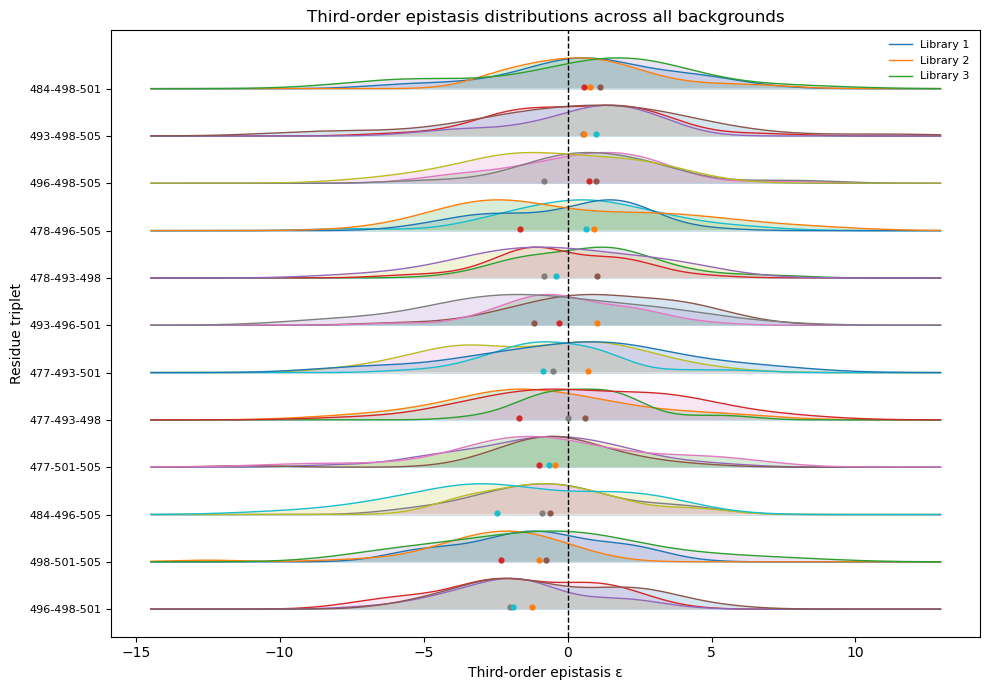

In [40]:
# Figure 3.17-style ridgeline distributions for selected third-order epistasis terms.

plot_df = third_order_epistasis[
    third_order_epistasis["residue_triplet"].isin(third_order_triplet_order)
].copy()

x_min = plot_df["epsilon_3"].min()
x_max = plot_df["epsilon_3"].max()
x_padding = 0.08 * (x_max - x_min)

x_grid = np.linspace(
    x_min - x_padding,
    x_max + x_padding,
    400
)

library_ids = sorted(plot_df["library_id"].unique())

fig, ax = plt.subplots(figsize=(10, 7))

ridge_height = 0.65

for triplet_idx, residue_triplet in enumerate(third_order_triplet_order):
    y_base = len(third_order_triplet_order) - triplet_idx

    for library_id in library_ids:
        sub = plot_df[
            (plot_df["residue_triplet"] == residue_triplet) &
            (plot_df["library_id"] == library_id)
        ]

        values = sub["epsilon_3"].dropna().values
        density = safe_kde(values, x_grid)

        y = y_base + density * ridge_height

        ax.plot(
            x_grid,
            y,
            linewidth=1.0,
            label=f"Library {library_id}" if triplet_idx == 0 else None
        )

        ax.fill_between(
            x_grid,
            y_base,
            y,
            alpha=0.18
        )

        # Mark the median of each library distribution.
        median_value = np.median(values)
        ax.scatter(
            median_value,
            y_base + 0.04,
            s=12,
            zorder=3
        )

    ax.hlines(
        y_base,
        x_grid.min(),
        x_grid.max(),
        linewidth=0.4,
        alpha=0.4
    )

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
    color="black"
)

ax.set_yticks([len(third_order_triplet_order) - i for i in range(len(third_order_triplet_order))])
ax.set_yticklabels(third_order_triplet_order, fontsize=8)

ax.set_xlabel("Third-order epistasis ε")
ax.set_ylabel("Residue triplet")
ax.set_title("Third-order epistasis distributions across all backgrounds")
ax.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "figure_3_17_third_order_epistasis_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
figure_3_17_distribution_summary = (
    plot_df
    .groupby(["library_id", "residue_triplet"], as_index=False)
    .agg(
        n_backgrounds=("epsilon_3", "size"),
        mean_epsilon_3=("epsilon_3", "mean"),
        median_epsilon_3=("epsilon_3", "median"),
        sd_epsilon_3=("epsilon_3", "std"),
        min_epsilon_3=("epsilon_3", "min"),
        max_epsilon_3=("epsilon_3", "max"),
        mean_abs_epsilon_3=("abs_epsilon_3", "mean"),
        median_abs_epsilon_3=("abs_epsilon_3", "median"),
    )
)

figure_3_17_distribution_summary.to_csv(
    CHECKPOINT_DIR / "figure_3_17_third_order_epistasis_distribution_summary.csv",
    index=False
)

figure_3_17_distribution_summary.head()

,library_id,residue_triplet,n_backgrounds,mean_epsilon_3,median_epsilon_3,sd_epsilon_3,min_epsilon_3,max_epsilon_3,mean_abs_epsilon_3,median_abs_epsilon_3
0,1,477-493-498,32,-1.081157,-1.691102,3.313778,-8.248893,6.406261,2.773010,2.009888
1,1,477-493-501,32,-1.154985,-0.522480,3.141067,-7.592871,4.986162,2.696056,2.715723
2,1,477-501-505,32,-0.850766,-0.661852,2.831436,-8.001601,5.264799,2.275025,1.522273
3,1,478-493-498,32,0.842594,1.015897,2.381844,-3.818510,7.247060,2.001220,1.567710
4,1,478-496-505,32,0.531399,0.635660,2.757832,-7.596489,6.442906,2.108398,1.601775


## Exploratory triplet-aware interaction network

This exploratory visualization overlays selected third-order interactions onto the pairwise epistasis network.

The node layout is data-aware and reflects both pairwise interaction strength and selected third-order interaction magnitude. Edges summarize pairwise epistasis, while filled triangles denote sign-consistent high-magnitude third-order interactions. Triangle color indicates the sign of the cross-library mean median third-order epistasis, and triangle opacity scales with effect magnitude.

This figure is intended as an integrative visual summary rather than a dissertation-style canonical network figure.

In [42]:
# Build third-order network summary for exploratory triplet overlay.
# This is intentionally self-contained so the notebook can run cleanly top-to-bottom.

third_order_network_summary = (
    third_order_epistasis_summary
    .groupby("residue_triplet", as_index=False)
    .agg(
        cross_library_mean_epsilon_3=("median_epsilon_3", "mean"),
        cross_library_mean_abs_epsilon_3=("median_abs_epsilon_3", "mean"),
        cross_library_sd_epsilon_3=("median_epsilon_3", "std"),
    )
)

third_order_sign_wide = (
    third_order_epistasis_summary
    .pivot(
        index="residue_triplet",
        columns="library_id",
        values="median_epsilon_3"
    )
    .rename(columns=lambda x: f"Library {x}")
    .reset_index()
)

third_order_network_summary = third_order_network_summary.merge(
    third_order_sign_wide,
    on="residue_triplet",
    how="left"
)

third_order_network_summary["all_same_sign"] = (
    np.sign(third_order_network_summary["Library 1"]) ==
    np.sign(third_order_network_summary["Library 2"])
) & (
    np.sign(third_order_network_summary["Library 1"]) ==
    np.sign(third_order_network_summary["Library 3"])
)

third_order_network_summary.to_csv(
    CHECKPOINT_DIR / "exploratory_third_order_network_summary.csv",
    index=False
)

third_order_network_summary.head()

,residue_triplet,cross_library_mean_epsilon_3,cross_library_mean_abs_epsilon_3,cross_library_sd_epsilon_3,Library 1,Library 2,Library 3,all_same_sign
0,477-478-484,0.423680,1.787019,0.122111,0.504920,0.482867,0.283255,True
1,477-478-493,0.297029,1.756565,0.320874,0.384130,0.565360,-0.058403,False
2,477-478-496,-0.297430,2.131394,0.240302,-0.538782,-0.058192,-0.295315,True
3,477-478-498,-0.335767,1.795759,0.755222,-1.073786,0.435556,-0.369070,False
4,477-478-501,-0.518071,1.956988,0.417466,-0.972733,-0.429448,-0.152033,True


In [43]:
from itertools import combinations
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

# ---------------------------------
# Helper: build triangle coordinates
# ---------------------------------
def triangle_from_triplet(triplet, node_positions_dict):
    """
    Return (nodes, coords) for a residue triplet like '496-498-501'.
    """
    nodes = triplet.split("-")
    coords = np.array([node_positions_dict[node] for node in nodes], dtype=float)
    return nodes, coords


def scale_alpha(value, vmin, vmax, alpha_min=0.10, alpha_max=0.45):
    """
    Scale fill opacity by magnitude.
    """
    if vmax == vmin:
        return (alpha_min + alpha_max) / 2
    return alpha_min + (value - vmin) * (alpha_max - alpha_min) / (vmax - vmin)


# --------------------------------------------------------
# Keep only sign-consistent, strongest triplets for overlay
# --------------------------------------------------------
N_TRIPLET_OVERLAYS = 8

third_order_network_summary_for_overlay = (
    third_order_network_summary
    .query("all_same_sign")
    .sort_values("cross_library_mean_abs_epsilon_3", ascending=False)
    .head(N_TRIPLET_OVERLAYS)
    .copy()
)

third_order_network_summary_for_overlay.to_csv(
    CHECKPOINT_DIR / "exploratory_triplet_overlay_inventory.csv",
    index=False
)

display(third_order_network_summary_for_overlay)


# ------------------------------------------------------
# Build a triplet-aware layout using pairwise + triplets
# ------------------------------------------------------
G_layout = nx.Graph()

for site in SITE_LABELS:
    G_layout.add_node(site)

# Add pairwise edges with weights based on pairwise magnitude.
for _, row in pairwise_network_summary.iterrows():
    site_a, site_b = row["residue_pair"].split("-")

    G_layout.add_edge(
        site_a,
        site_b,
        weight=0.5 + row["cross_library_median_abs_epsilon"]
    )

# Add triplet-derived attraction among sites within strong triplets.
for _, row in third_order_network_summary_for_overlay.iterrows():
    triplet_sites = row["residue_triplet"].split("-")
    triplet_weight = 0.5 + row["cross_library_mean_abs_epsilon_3"]

    for site_a, site_b in combinations(triplet_sites, 2):
        if G_layout.has_edge(site_a, site_b):
            G_layout[site_a][site_b]["weight"] += triplet_weight
        else:
            G_layout.add_edge(site_a, site_b, weight=triplet_weight)

# Reproducible layout.
node_positions_triplet_aware = nx.spring_layout(
    G_layout,
    weight="weight",
    seed=42,
    k=0.9,
    iterations=500
)

node_positions_triplet_aware

,residue_triplet,cross_library_mean_epsilon_3,cross_library_mean_abs_epsilon_3,cross_library_sd_epsilon_3,Library 1,Library 2,Library 3,all_same_sign
55,498-501-505,-1.348295,2.214110,0.840901,-0.978989,-2.310652,-0.755243,True
52,496-498-501,-1.706031,2.209381,0.400782,-1.990934,-1.879411,-1.247749,True
2,477-478-496,-0.297430,2.131394,0.240302,-0.538782,-0.058192,-0.295315,True
6,477-484-493,0.450180,2.074448,0.613915,0.173725,0.023102,1.153713,True
50,493-498-505,0.705446,2.023723,0.253710,0.553377,0.998333,0.564627,True
42,484-496-505,-1.314230,2.008415,0.999406,-0.598378,-0.888270,-2.456043,True
39,484-493-505,0.571110,1.978727,0.690727,0.151050,0.193973,1.368308,True
4,477-478-501,-0.518071,1.956988,0.417466,-0.972733,-0.429448,-0.152033,True


{'477': array([0.02857419, 0.866969  ]),
 '478': array([0.86004864, 0.66696314]),
 '484': array([-1.        , -0.07850918]),
 '493': array([-0.63978563,  0.38130479]),
 '496': array([0.17216978, 0.0292522 ]),
 '498': array([ 0.23582635, -0.90348489]),
 '501': array([ 0.78848356, -0.32236053]),
 '505': array([-0.44531689, -0.64013455])}

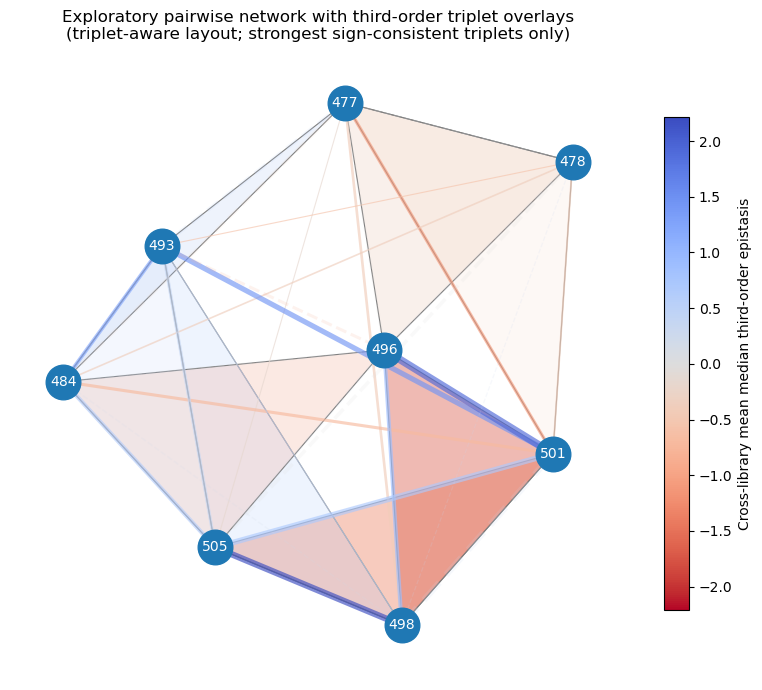

In [44]:
fig, ax = plt.subplots(figsize=(8, 7))

# ------------------------------------------------
# Draw third-order triangles first (behind edges)
# ------------------------------------------------
triplet_mag_min = third_order_network_summary_for_overlay["cross_library_mean_abs_epsilon_3"].min()
triplet_mag_max = third_order_network_summary_for_overlay["cross_library_mean_abs_epsilon_3"].max()

triangle_cmap = plt.get_cmap("coolwarm_r")
triangle_abs_limit = third_order_network_summary_for_overlay["cross_library_mean_abs_epsilon_3"].max()
triangle_norm = mpl.colors.Normalize(
    vmin=-triangle_abs_limit,
    vmax=triangle_abs_limit
)

for _, row in third_order_network_summary_for_overlay.iterrows():
    triplet = row["residue_triplet"]
    nodes, coords = triangle_from_triplet(triplet, node_positions_triplet_aware)

    mean_val = row["cross_library_mean_epsilon_3"]
    mag_val = row["cross_library_mean_abs_epsilon_3"]

    face_rgba = list(triangle_cmap(triangle_norm(mean_val)))
    face_rgba[-1] = scale_alpha(
        mag_val,
        triplet_mag_min,
        triplet_mag_max,
        alpha_min=0.12,
        alpha_max=0.42
    )

    patch = Polygon(
        coords,
        closed=True,
        facecolor=face_rgba,
        edgecolor="gray",
        linewidth=0.8,
        linestyle="-",
        zorder=1
    )
    ax.add_patch(patch)


# -----------------------------------------
# Draw pairwise network on top of triangles
# -----------------------------------------
nx.draw_networkx_nodes(
    G_pairwise,
    pos=node_positions_triplet_aware,
    node_size=620,
    ax=ax
)

nx.draw_networkx_labels(
    G_pairwise,
    pos=node_positions_triplet_aware,
    font_size=10,
    font_color="white",
    ax=ax
)

solid_edges = []
solid_widths = []
solid_colors = []

dashed_edges = []
dashed_widths = []
dashed_colors = []

pairwise_cmap = plt.get_cmap("coolwarm_r")
pairwise_norm = mpl.colors.Normalize(vmin=-edge_abs_limit, vmax=edge_abs_limit)

for u, v, data in G_pairwise.edges(data=True):
    edge_tuple = (u, v)

    color = pairwise_cmap(pairwise_norm(data["mean_epsilon"]))
    width = scale_linewidth(
        data["median_abs_epsilon"],
        edge_mag_min,
        edge_mag_max
    )

    if data["edge_style"] == "solid":
        solid_edges.append(edge_tuple)
        solid_widths.append(width)
        solid_colors.append(color)
    else:
        dashed_edges.append(edge_tuple)
        dashed_widths.append(width)
        dashed_colors.append(color)

nx.draw_networkx_edges(
    G_pairwise,
    pos=node_positions_triplet_aware,
    edgelist=solid_edges,
    width=solid_widths,
    edge_color=solid_colors,
    alpha=0.65,
    ax=ax
)

nx.draw_networkx_edges(
    G_pairwise,
    pos=node_positions_triplet_aware,
    edgelist=dashed_edges,
    width=dashed_widths,
    edge_color=dashed_colors,
    alpha=0.16,
    style="dashed",
    ax=ax
)


# ----------------
# Triangle colorbar
# ----------------
sm = mpl.cm.ScalarMappable(cmap=triangle_cmap, norm=triangle_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.78)
cbar.set_label("Cross-library mean median third-order epistasis")

ax.set_title(
    "Exploratory pairwise network with third-order triplet overlays\n"
    "(triplet-aware layout; strongest sign-consistent triplets only)"
)
ax.axis("off")

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "exploratory_pairwise_network_with_triplet_overlays.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
exploratory_triplet_overlay_summary = third_order_network_summary_for_overlay[
    [
        "residue_triplet",
        "Library 1",
        "Library 2",
        "Library 3",
        "cross_library_mean_epsilon_3",
        "cross_library_mean_abs_epsilon_3",
        "all_same_sign",
    ]
].copy()

exploratory_triplet_overlay_summary

,residue_triplet,Library 1,Library 2,Library 3,cross_library_mean_epsilon_3,cross_library_mean_abs_epsilon_3,all_same_sign
55,498-501-505,-0.978989,-2.310652,-0.755243,-1.348295,2.214110,True
52,496-498-501,-1.990934,-1.879411,-1.247749,-1.706031,2.209381,True
2,477-478-496,-0.538782,-0.058192,-0.295315,-0.297430,2.131394,True
6,477-484-493,0.173725,0.023102,1.153713,0.450180,2.074448,True
50,493-498-505,0.553377,0.998333,0.564627,0.705446,2.023723,True
42,484-496-505,-0.598378,-0.888270,-2.456043,-1.314230,2.008415,True
39,484-493-505,0.151050,0.193973,1.368308,0.571110,1.978727,True
4,477-478-501,-0.972733,-0.429448,-0.152033,-0.518071,1.956988,True


## Output inventory

This section records the figure and checkpoint files generated by this notebook.

In [46]:
epistasis_figure_inventory = []

for path in sorted(FIGURE_DIR.glob("*.png")):
    epistasis_figure_inventory.append({
        "figure_file": path.name,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "size_bytes": path.stat().st_size,
    })

epistasis_figure_inventory = pd.DataFrame(epistasis_figure_inventory)

epistasis_figure_inventory.to_csv(
    CHECKPOINT_DIR / "epistasis_figure_inventory.csv",
    index=False
)

epistasis_figure_inventory

,figure_file,relative_path,size_bytes
0,epistasis_model_r2_by_order.png,figures/epistasis/epistasis_model_r2_by_order.png,160833
1,exploratory_pairwise_network_with_triplet_over...,figures/epistasis/exploratory_pairwise_network...,521638
2,exploratory_regression_coefficient_power_by_or...,figures/epistasis/exploratory_regression_coeff...,256985
3,figure_3_12_pairwise_epistasis_heatmaps.png,figures/epistasis/figure_3_12_pairwise_epistas...,1177822
4,figure_3_13_pairwise_epistasis_distributions.png,figures/epistasis/figure_3_13_pairwise_epistas...,780694
5,figure_3_14_pairwise_epistasis_cross_library_c...,figures/epistasis/figure_3_14_pairwise_epistas...,128646
6,figure_3_15_pairwise_epistatic_interaction_net...,figures/epistasis/figure_3_15_pairwise_epistat...,338432
7,figure_3_16_variance_decomposition_by_order.png,figures/epistasis/figure_3_16_variance_decompo...,255806
8,figure_3_17_third_order_epistasis_distribution...,figures/epistasis/figure_3_17_third_order_epis...,492450
9,figure_3_18_third_order_epistasis_cross_librar...,figures/epistasis/figure_3_18_third_order_epis...,127826


In [47]:
epistasis_checkpoint_inventory = []

for path in sorted(CHECKPOINT_DIR.glob("*epistasis*.csv")) + sorted(CHECKPOINT_DIR.glob("figure_3_*.csv")) + sorted(CHECKPOINT_DIR.glob("table_3_7*.csv")):
    epistasis_checkpoint_inventory.append({
        "checkpoint_file": path.name,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "size_bytes": path.stat().st_size,
    })

epistasis_checkpoint_inventory = (
    pd.DataFrame(epistasis_checkpoint_inventory)
    .drop_duplicates()
    .sort_values("checkpoint_file")
    .reset_index(drop=True)
)

epistasis_checkpoint_inventory.to_csv(
    CHECKPOINT_DIR / "epistasis_checkpoint_inventory.csv",
    index=False
)

epistasis_checkpoint_inventory

,checkpoint_file,relative_path,size_bytes
0,archived_epistasis_candidate_files.csv,outputs/checkpoints/archived_epistasis_candida...,361
1,epistasis_checkpoint_inventory.csv,outputs/checkpoints/epistasis_checkpoint_inven...,3501
2,epistasis_coefficients.csv,outputs/checkpoints/epistasis_coefficients.csv,231581
3,epistasis_dissertation_figure_manifest.csv,outputs/checkpoints/epistasis_dissertation_fig...,1097
4,epistasis_figure_inventory.csv,outputs/checkpoints/epistasis_figure_inventory...,1312
5,epistasis_input_table.csv,outputs/checkpoints/epistasis_input_table.csv,37140
6,epistasis_model_summary.csv,outputs/checkpoints/epistasis_model_summary.csv,4196
7,epistasis_predictions.csv,outputs/checkpoints/epistasis_predictions.csv,820293
8,epistasis_variance_decomposition_by_order.csv,outputs/checkpoints/epistasis_variance_decompo...,1812
9,epistasis_variance_decomposition_by_order_with...,outputs/checkpoints/epistasis_variance_decompo...,2339


## Epistasis analysis summary

This notebook reproduces the dissertation-associated epistasis analysis from the processed W/O genotype landscape.

The workflow starts from the 3-library × 256-genotype W/O landscape table, encodes the eight design sites as binary Wuhan/Omicron states, and computes background-dependent pairwise and third-order epistasis values.

Generated dissertation-style outputs include:

- Figure 3.12: pairwise epistasis heatmaps across experimental libraries
- Figure 3.13: pairwise epistasis distributions across genetic backgrounds
- Figure 3.14: cross-library comparison of signed pairwise epistasis
- Figure 3.15: pairwise epistatic interaction network
- Figure 3.16: Walsh-style variance decomposition by epistasis order
- Figure 3.17: third-order epistasis distributions across genetic backgrounds
- Figure 3.18: cross-library comparison of third-order epistatic interaction coefficients
- Table 3.7: cross-library correlations of pairwise epistasis estimates

Additional exploratory outputs include:

- 0/1 regression-coefficient power by interaction order
- triplet-aware network overlay combining pairwise edges with selected sign-consistent third-order interactions

The Walsh-style decomposition is retained as the dissertation-facing variance decomposition. The 0/1 regression-coefficient power plot is retained as an exploratory, parameterization-dependent comparison.

The notebook writes reproducible figure files to `figures/epistasis/` and summary/checkpoint tables to `outputs/checkpoints/`.